In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2
import itertools
import mpltern

import warnings
def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(**{"aspect": "equal", "xlim": lims, "ylim": lims})
    return ax

# Suppress warnings
warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [17]:
def load_evidence(fn, ds_name, metrics=False):
    # we only want derived since we're going to compare gene ids
    j = pd.read_json(fn)

    derived = j["derived"].apply(pd.Series).add_prefix("derived_")
    extracted = j["extracted"].apply(pd.Series).add_prefix("extracted_")
    source = j["source"].apply(pd.Series)#.add_prefix("source_")


    if metrics:
        source_metrics = source["source_metrics"].apply(pd.Series).add_prefix("source_metrics_")
        source = pd.concat([source, source_metrics], axis=1)
    # drop the original columns

    df = pd.concat([derived, extracted, source], axis=1)
    df["ds_name"] = ds_name

    # normalize the string values for cell types
    df["extracted_cell_type_label"] = df["extracted_cell_type_label"].str.strip().str.upper()
    # df["extracted_cell_type_id"] = df["extracted_cell_type_id"].str.strip().str.upper()

    df["derived_cell_type_label"] = df["derived_cell_type_label"].str.strip().str.upper()
    df["derived_cell_type_id"] = df["derived_cell_type_id"].str.strip().str.upper()
    
    # normalize the string values for genes
    df["extracted_feature_name"] = df["extracted_feature_name"].str.strip().str.upper()
    df["derived_feature_name"] = df["derived_feature_name"].str.strip().str.upper()

    # df["extracted_feature_identifier"] = df["extracted_feature_identifier"].str.strip().str.upper()
    df["derived_feature_identifier"] = df["derived_feature_identifier"].str.strip().str.upper()


    return df

def set_itx(a, b, vals=False):
    itx = np.intersect1d(a, b)
    if vals:
        return itx
    return itx.shape[0]

def set_diff(a, b, vals=False):
    diff = np.setdiff1d(a, b)
    if vals:
        return diff
    return diff.shape[0]

def set_cmp(a,b, vals=False):
    return (set_diff(a,b,vals), set_itx(a,b,vals), set_diff(b,a,vals))

def get_ctmap(ctmap_fn):
    with open(ctmap_fn, 'r') as file:
        map_dict = json.load(file)
        upper_map = {k.upper(): [v.upper() for v in vals] for k, vals in map_dict.items()}
        rev_map = {v: k for k, vals in upper_map.items() for v in vals}
    return (upper_map, rev_map)

In [18]:
# ds = "adipose_Hildreth2021"
# ds = "adipose_Vijay2019"
# ds = "bone_He2021"
# ds_deg = "heart_Tucker2020"
# ds_hmn = "heart_Tucker2020"

# ds_deg = "bladder_Yu2019"
# ds_hmn = "bladder_Yu2019"

# ds_deg = "adipose_Emont2022"
# ds_hmn = "adipose_Emont2022"

ds_deg = "adipose_Hildreth2021"
ds_hmn = "adipose_Hildreth2021"
ds_llm = "adipose_Hildreth2021"

ds = ["adipose_Hildreth2021", "bone_He2021", "heart_Tucker2020", "bladder_Yu2019", "adipose_Emont2022"]

data = []

for ds_hmn, ds_deg in zip(ds, ds):
    fn_hmn   = f"../../data/{ds_hmn}/evidence_human/evidence.json"
    fn_deg   = f"../../data/{ds_deg}/evidence_deg/evidence_unfiltered_metrics.json"
    # fn_llm   = f"../../data/{ds_llm}/evidence_llm_llama3.2_MarkerGeneListStrict_4efcc22/evidence.json"

    hmn = load_evidence(fn_hmn, ds_hmn)
    deg = load_evidence(fn_deg, ds_deg, metrics=True)
    # llm = load_evidence(fn_llm, ds_llm)

    # drop everything ecept for the derived and source columns
    hmn = hmn.loc[:, hmn.columns.str.contains("derived_|source_")].rename(columns=lambda x: x.replace("derived_", "")).dropna(subset=["feature_identifier"])
    deg = deg.loc[:, deg.columns.str.contains("derived_|source_")].rename(columns=lambda x: x.replace("derived_", "")).dropna(subset=["feature_identifier"]).drop(columns=["source_metrics"]).rename(columns=lambda x: x.replace("source_metrics_", ""))


    img = hmn.query("source_type == 'image'")
    txt = hmn.query("source_type == 'text'")


    celltypes = np.union1d(hmn["cell_type_id"].unique(), deg["cell_type_id"].unique())
    data.append({"ds_name": ds_hmn, "deg": deg, "img": img, "txt": txt, "celltypes": celltypes})

In [15]:
deg

,organism,cell_type_id,cell_type_label,cell_source,cell_state,feature_name,feature_type,feature_identifier,feature_identifier_type,source_type,source_rationale,source_id,p_corr,log_fc
0,homo_sapiens,None,LBM1,bone,None,H2AFZ,ensembl,ENSG00000164032,ensembl,deg,unfiltered,Degs human_limb&bone Fig. 1d,0.000000,1.734192
1,homo_sapiens,None,LBM1,bone,None,RANBP1,ensembl,ENSG00000099901,ensembl,deg,unfiltered,Degs human_limb&bone Fig. 1d,0.000000,1.468134
2,homo_sapiens,None,LBM1,bone,None,DUSP6,ensembl,ENSG00000139318,ensembl,deg,unfiltered,Degs human_limb&bone Fig. 1d,0.000000,2.428796
3,homo_sapiens,None,LBM1,bone,None,HMGA1,ensembl,ENSG00000137309,ensembl,deg,unfiltered,Degs human_limb&bone Fig. 1d,0.000000,1.814476
4,homo_sapiens,None,LBM1,bone,None,HSPD1,ensembl,ENSG00000144381,ensembl,deg,unfiltered,Degs human_limb&bone Fig. 1d,0.000000,1.229231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4247,homo_sapiens,None,MACROPHAGE,bone,None,MS4A7,ensembl,ENSG00000166927,ensembl,deg,unfiltered,Degs human calvaria Fig. 6b,0.000896,10.819491
4248,homo_sapiens,None,MACROPHAGE,bone,None,GIMAP2,ensembl,ENSG00000106560,ensembl,deg,unfiltered,Degs human calvaria Fig. 6b,0.000909,6.025243
4249,homo_sapiens,None,MACROPHAGE,bone,None,JAML,ensembl,ENSG00000160593,ensembl,deg,unfiltered,Degs human calvaria Fig. 6b,0.000997,8.264292
4250,homo_sapiens,None,MACROPHAGE,bone,None,SIPA1,ensembl,ENSG00000213445,ensembl,deg,unfiltered,Degs human calvaria Fig. 6b,0.000745,2.689635


In [ ]:
feature = "feature_identifier"

hmn_features = pd.Series(hmn[feature].unique()).dropna().tolist()
deg_features = pd.Series(deg[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn_features, deg_features)                # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()      # normalized counts
lv, xv, rv  = set_cmp(hmn_features, deg_features, vals=True)  # actual lists

gene_vals = [l,x,r]
gene_nvals = [nl,nx,nr]

print(f"Human v DEG ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

# feature = "cell_type_label" # eventually change this to comparing based on a map we can create
feature = "cell_type_id"

hmn_features = pd.Series(hmn[feature].unique()).dropna().tolist()
deg_features = pd.Series(deg[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn_features, deg_features)               # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()     # normalized counts
lv, xv, rv  = set_cmp(hmn_features, deg_features, vals=True) # actual lists

ct_vals = [l,x,r]
ct_nvals = [nl,nx,nr]

print(f"Human v DEG ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

# Define the multi-level column structure and data
columns = pd.MultiIndex.from_product(
    [["cell_type_id", "feature_name"], ["left", "itx", "right"]],
    names=["Feature", "Set Comparison"]
)

data = [
    ct_vals +  gene_vals,  # raw values
   ct_nvals + gene_nvals  # normalized values
]

# Create the DataFrame
df = pd.DataFrame(data, columns=columns, index=["raw", "norm"])
df



Human v DEG (feature_identifier)
	left	itx	right
raw	3	81	9278
norm	0.00	0.01	0.99
Human v DEG (cell_type_id)
	left	itx	right
raw	0	10	2
norm	0.00	0.83	0.17


Feature        cell_type_id                      feature_name             \
Set Comparison         left        itx     right         left        itx   
raw                     0.0  10.000000  2.000000      3.00000  81.000000   
norm                    0.0   0.833333  0.166667      0.00032   0.008652   

Feature                      
Set Comparison        right  
raw             9278.000000  
norm               0.991028

In [148]:
rv

array(['B CELL', 'MYELOID-LIKE CELLS'], dtype='<U21')

# DEG <-> IMG <-> TXT <-> comparisons

In [149]:
celltypes

array(['ADIPOCYTE', 'B CELL', 'DENDRITIC CELL', 'ENDOTHELIUM',
       'INNATE LYMPHOID CELLS', 'MACROPHAGE', 'MONOCYTE',
       'MYELOID-LIKE CELLS', 'NATURAL KILLER CELL', 'NEUTROPHIL',
       'SMOOTH MUSCLE CELLS', 'T CELL'], dtype=object)

In [138]:
import matplotlib.patches as patches


def hatch_cell(ax, i, j, hatch='//', color='white'):
    rect = patches.Rectangle((j - 0.5, i - 0.5), 1, 1,
                             linewidth=0, edgecolor='black', facecolor=color,
                             hatch=hatch, zorder=2, alpha=0.8)
    ax.add_patch(rect)



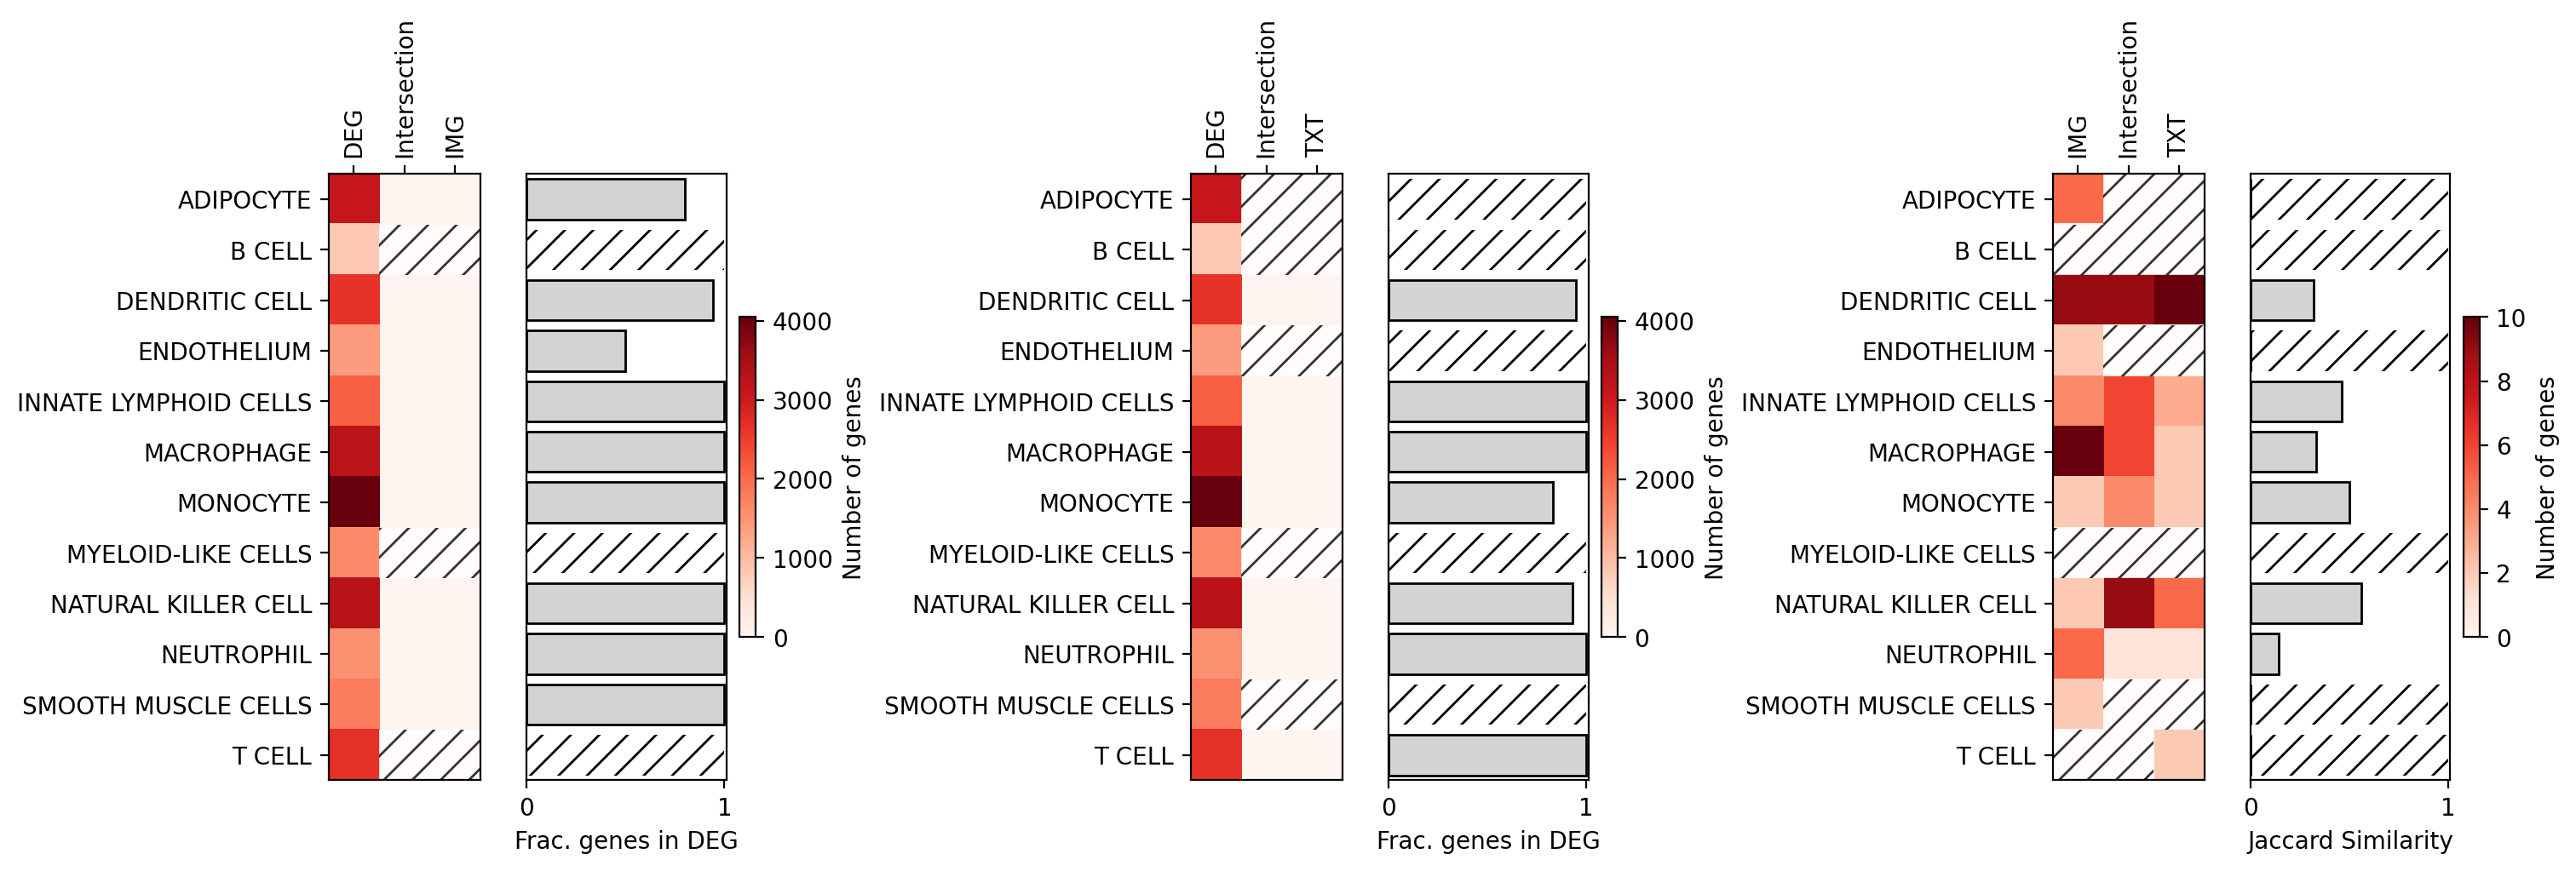

In [150]:
cmps = [
    ("deg", "img"),
    ("deg", "txt"),
    ("img", "txt")
]
fig, axs = plt.subplots(figsize=(15,5), ncols=6, constrained_layout=True)

for idx, (a, b) in enumerate(cmps):

    t1 = globals()[a].groupby(["cell_type_id"])["feature_identifier"].apply(list).reindex(celltypes, fill_value=[])
    t2 = globals()[b].groupby(["cell_type_id"])["feature_identifier"].apply(list).reindex(celltypes, fill_value=[])

    l = t1.combine(t2, lambda a, b: np.setdiff1d(a, b).shape[0]).rename(f"{a}")
    x = t1.combine(t2, lambda a, b: np.intersect1d(a, b).shape[0]).rename("x")
    r = t1.combine(t2, lambda a, b: np.setdiff1d(b, a).shape[0]).rename(f"{b}")
    mtx = pd.concat([l,x,r], axis=1)


    ax = axs[2*idx]
    xlabels = [f"{a.upper()}", "Intersection", f"{b.upper()}"]
    eye = mtx.values

    cax = ax.imshow(eye, cmap="Reds")#, vmin=0, vmax=1)

    not_in_t1 = np.where(t1.apply(lambda x: len(x)) == 0)[0]
    not_in_t2 = np.where(t2.apply(lambda x: len(x)) == 0)[0]

    # Apply hatch to specific cells
    for i in not_in_t1:
        hatch_cell(ax, i, 0)

    for i in not_in_t2:
        hatch_cell(ax, i, 2)

    for i in np.unique(np.concatenate([not_in_t1, not_in_t2])):
        hatch_cell(ax, i, 1)


    ax.set(**{
        "xticks": np.arange(len(xlabels)),
        "yticks": np.arange(len(celltypes)),
        "xticklabels": xlabels,
        "yticklabels": celltypes,
    })
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')  # Set the label position at the top

    ax = axs[2*idx+1]
    if a == "deg":
        xlabel = "Frac. genes in DEG"
        jac = eye[:,1] / (eye[:,2] + eye[:,1])
    else:
        xlabel = "Jaccard Similarity"
        jac = eye[:,1] / (eye[:,1] + eye[:,2] + eye[:,0])
    jac = jac[::-1]

    ax.barh(np.arange(len(celltypes)), jac, edgecolor="black", facecolor="lightgrey")

    highlight_indices = np.unique(np.concatenate([not_in_t1, not_in_t2]))

    # Overlay bars with hatch patterns for highlighted indices
    for i in highlight_indices:
        ax.barh(len(celltypes)-i-1, 1, edgecolor="black",
                facecolor="none", hatch='//', linewidth=0)
        
    ax.set(**{
        "yticks": np.arange(len(celltypes)),
        "yticklabels": [],
        "xlabel": xlabel,
        "xlim": (0,1.01),
        "ylim": (-0.5, len(celltypes)-0.5)
    })
    ax.yaxis.set_visible(False)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
    plt.colorbar(cax, ax=ax, fraction=0.08, pad=0.04, label="Number of genes")


In [143]:
t1 = txt.groupby(["cell_type_id"])["feature_identifier"].apply(list).reindex(celltypes, fill_value=[])
t2 = deg.groupby(["cell_type_id"])["feature_identifier"].apply(list).reindex(celltypes, fill_value=[])

t1.combine(t2, lambda a, b: np.setdiff1d(a, b)).rename("txt")

cell_type_id
ADIPOCYTE                             [ENSG00000121440, ENSG00000196821]
CARDIOMYOCYTE          [ENSG00000105048, ENSG00000120729, ENSG0000014...
ENDOTHELIUM            [ENSG00000037280, ENSG00000102010, ENSG0000011...
FIBROBLAST             [ENSG00000017427, ENSG00000086991, ENSG0000017...
LYMPHOCYTE             [ENSG00000149534, ENSG00000172236, ENSG0000019...
MACROPHAGE                                             [ENSG00000050767]
NEURON                                                                []
PERICYTE                                                              []
SMOOTH MUSCLE CELLS                                                   []
Name: txt, dtype: object

In [144]:
ft = "ENSG00000121440"

ct = "ADIPOCYTE"


print(txt.query(f"feature_identifier == '{ft}' & cell_type_id == '{ct}'").iloc[0].source_rationale)
print(txt.query(f"feature_identifier == '{ft}' & cell_type_id == '{ct}'").iloc[0].feature_name)

 It is interesting that in the left atrium, the putative PR interval gene PDZRN3 shows enriched expression in adipocytes (AUC_(AD)=0.76) and 2 of 12 atrial fibrillation genes show enriched expression in cardiomyocytes (CASQ2, AUC_(CM)=0.74) and endothelial cells (SYNE2, AUC_(EN)=0.74).
PDZRN3


In [145]:
txt.query(f"feature_identifier == '{ft}'")

,organism,cell_type_id,cell_type_label,cell_source,cell_state,feature_name,feature_type,feature_identifier,feature_identifier_type,source_type,source_rationale,source_id
453,homo_sapiens,CARDIOMYOCYTE,CARDIOMYOCYTES,heart - left ventricle,none,PDZRN3,gene,ENSG00000121440,ensembl,text,"In the left ventricle, 1 of the 11 putative ge...",text
457,homo_sapiens,ADIPOCYTE,ADIPOCYTES,heart - left atrium,none,PDZRN3,gene,ENSG00000121440,ensembl,text,"It is interesting that in the left atrium, th...",text


In [33]:
deg.query(f"cell_type_id == '{ct}' & feature_identifier == '{ft}'")

,organism,cell_type_id,cell_type_label,cell_source,cell_state,feature_name,feature_type,feature_identifier,feature_identifier_type,source_type,source_rationale,source_id,p_corr,log_fc


In [34]:
deg.cell_type_label.unique()

array(['CD8 GDT', 'CYTOTOXIC CD8 T', 'ILCS', 'MAIT', 'MNK', 'NAIVE CD4 T',
       'NAIVE CD8 T', 'NK-LIKE', 'TREG', 'CDC1', 'CDC2B', 'MYELOID-LIKE',
       'NCMO', 'PVM', 'APC', 'PREADIPOCYTE', 'ENDOTHELIAL',
       'SMOOTH MUSCLE', 'B CELL', 'TRNK', 'INK', 'ILC1', 'ILC2', 'ILC3',
       'ILCP-LIKE', 'MO-1', 'MO-2', 'IM', 'LAM', 'NEU', 'CDC2A', 'BC',
       'CCD8T', 'CD8GDT', 'ENDO', 'NCD4T', 'NCD8T', 'PAD', 'SMC'],
      dtype=object)

,cell_type_id,feature_identifier,organism,cell_type_label,cell_source,cell_state,feature_name,feature_type,feature_identifier_type,source_type,source_rationale,source_id,p_corr,log_fc
0,T CELL,ENSG00000153563,homo_sapiens,CD8 GDT,adipose,None,CD8A,ensembl,ensembl,deg,unfiltered,Cluster_Markers_CD45PosNeg,3.797655e-42,0.418533
1,T CELL,ENSG00000153563,homo_sapiens,CYTOTOXIC CD8 T,adipose,None,CD8A,ensembl,ensembl,deg,unfiltered,Cluster_Markers_CD45PosNeg,0.000000e+00,1.409670
2,T CELL,ENSG00000153563,homo_sapiens,MAIT,adipose,None,CD8A,ensembl,ensembl,deg,unfiltered,Cluster_Markers_CD45PosNeg,0.000000e+00,0.789704
3,T CELL,ENSG00000153563,homo_sapiens,NAIVE CD8 T,adipose,None,CD8A,ensembl,ensembl,deg,unfiltered,Cluster_Markers_CD45PosNeg,0.000000e+00,1.430139
4,INNATE LYMPHOID CELLS,ENSG00000115602,homo_sapiens,ILCS,adipose,None,IL1RL1,ensembl,ensembl,deg,unfiltered,Cluster_Markers_CD45PosNeg,8.279513e-256,1.018278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,DENDRITIC CELL,ENSG00000102970,homo_sapiens,CDC2B,adipose,None,CCL17,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Celltype_Myeloi,4.582068e-206,0.678153
165,DENDRITIC CELL,ENSG00000172724,homo_sapiens,CDC2A,adipose,None,CCL19,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Celltype_Myeloi,0.000000e+00,1.014033
166,DENDRITIC CELL,ENSG00000168685,homo_sapiens,CDC2A,adipose,None,IL7R,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Celltype_Myeloi,3.038692e-97,0.690765
167,DENDRITIC CELL,ENSG00000163220,homo_sapiens,CDC1,adipose,None,MIF,ensembl,ensembl,deg,unfiltered,DEG_Celltype_LeanvsObese,1.674105e-15,-0.187014


In [124]:
celltypes

txt_idx = txt.set_index(["cell_type_id", "feature_identifier"]).index
img_idx = img.set_index(["cell_type_id", "feature_identifier"]).index
deg_idx = deg.set_index(["cell_type_id", "feature_identifier"]).index

comm_img = deg_idx.intersection(img_idx)
comm_txt = deg_idx.intersection(txt_idx)


discussed_img     = deg.set_index(["cell_type_id", "feature_identifier"]).loc[comm_img].reset_index()
ct_img = discussed_img["cell_type_id"].unique()

avg_gene_per_ct   = discussed_img.groupby("cell_type_id")["feature_identifier"].apply(lambda x: len(x.unique())).mean()

not_discussed_img = deg.query("p_corr < 0.01").groupby("cell_type_id").apply(lambda x: x.nlargest(int(avg_gene_per_ct*1.10), "log_fc")).loc[ct_img].reset_index(drop=True)


discussed_txt     = deg.set_index(["cell_type_id", "feature_identifier"]).loc[comm_txt].reset_index()
ct_txt = discussed_txt["cell_type_id"].unique()
avg_gene_per_ct = discussed_txt.groupby("cell_type_id")["feature_identifier"].apply(lambda x: len(x.unique())).mean()

not_discussed_txt = deg.query("p_corr < 0.01").groupby("cell_type_id").apply(lambda x: x.nlargest(int(avg_gene_per_ct*1.10), "log_fc")).loc[ct_txt].reset_index(drop=True)


,index,cell_type_id,feature_identifier,organism,cell_type_label,cell_source,cell_state,feature_name,feature_type,feature_identifier_type,source_type,source_rationale,source_id,p_corr,log_fc
0,0,INNATE LYMPHOID CELLS,ENSG00000157404,homo_sapiens,ILCS,adipose,None,KIT,ensembl,ensembl,deg,unfiltered,Cluster_Markers_CD45PosNeg,0.000000e+00,1.082845
1,1,INNATE LYMPHOID CELLS,ENSG00000157404,homo_sapiens,ILC1,adipose,None,KIT,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Cellype_NK_ILCs,4.498529e-26,0.486517
2,2,INNATE LYMPHOID CELLS,ENSG00000157404,homo_sapiens,ILC2,adipose,None,KIT,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Cellype_NK_ILCs,2.985072e-216,0.415114
3,3,INNATE LYMPHOID CELLS,ENSG00000157404,homo_sapiens,ILC3,adipose,None,KIT,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Cellype_NK_ILCs,0.000000e+00,1.666024
4,4,INNATE LYMPHOID CELLS,ENSG00000157404,homo_sapiens,ILCP-LIKE,adipose,None,KIT,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Cellype_NK_ILCs,0.000000e+00,0.865993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,213,DENDRITIC CELL,ENSG00000078081,homo_sapiens,CDC2A,adipose,None,LAMP3,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Celltype_Myeloi,0.000000e+00,1.795362
214,214,DENDRITIC CELL,ENSG00000075618,homo_sapiens,CDC2A,adipose,None,FSCN1,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Celltype_Myeloi,0.000000e+00,1.293803
215,215,DENDRITIC CELL,ENSG00000168685,homo_sapiens,CDC2A,adipose,None,IL7R,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Celltype_Myeloi,3.038692e-97,0.690765
216,216,DENDRITIC CELL,ENSG00000125347,homo_sapiens,CDC2A,adipose,None,IRF1,ensembl,ensembl,deg,unfiltered,Cluster_Markers_Celltype_Myeloi,7.585676e-25,0.469242


In [117]:
avg_gene_per_ct

np.float64(8.142857142857142)

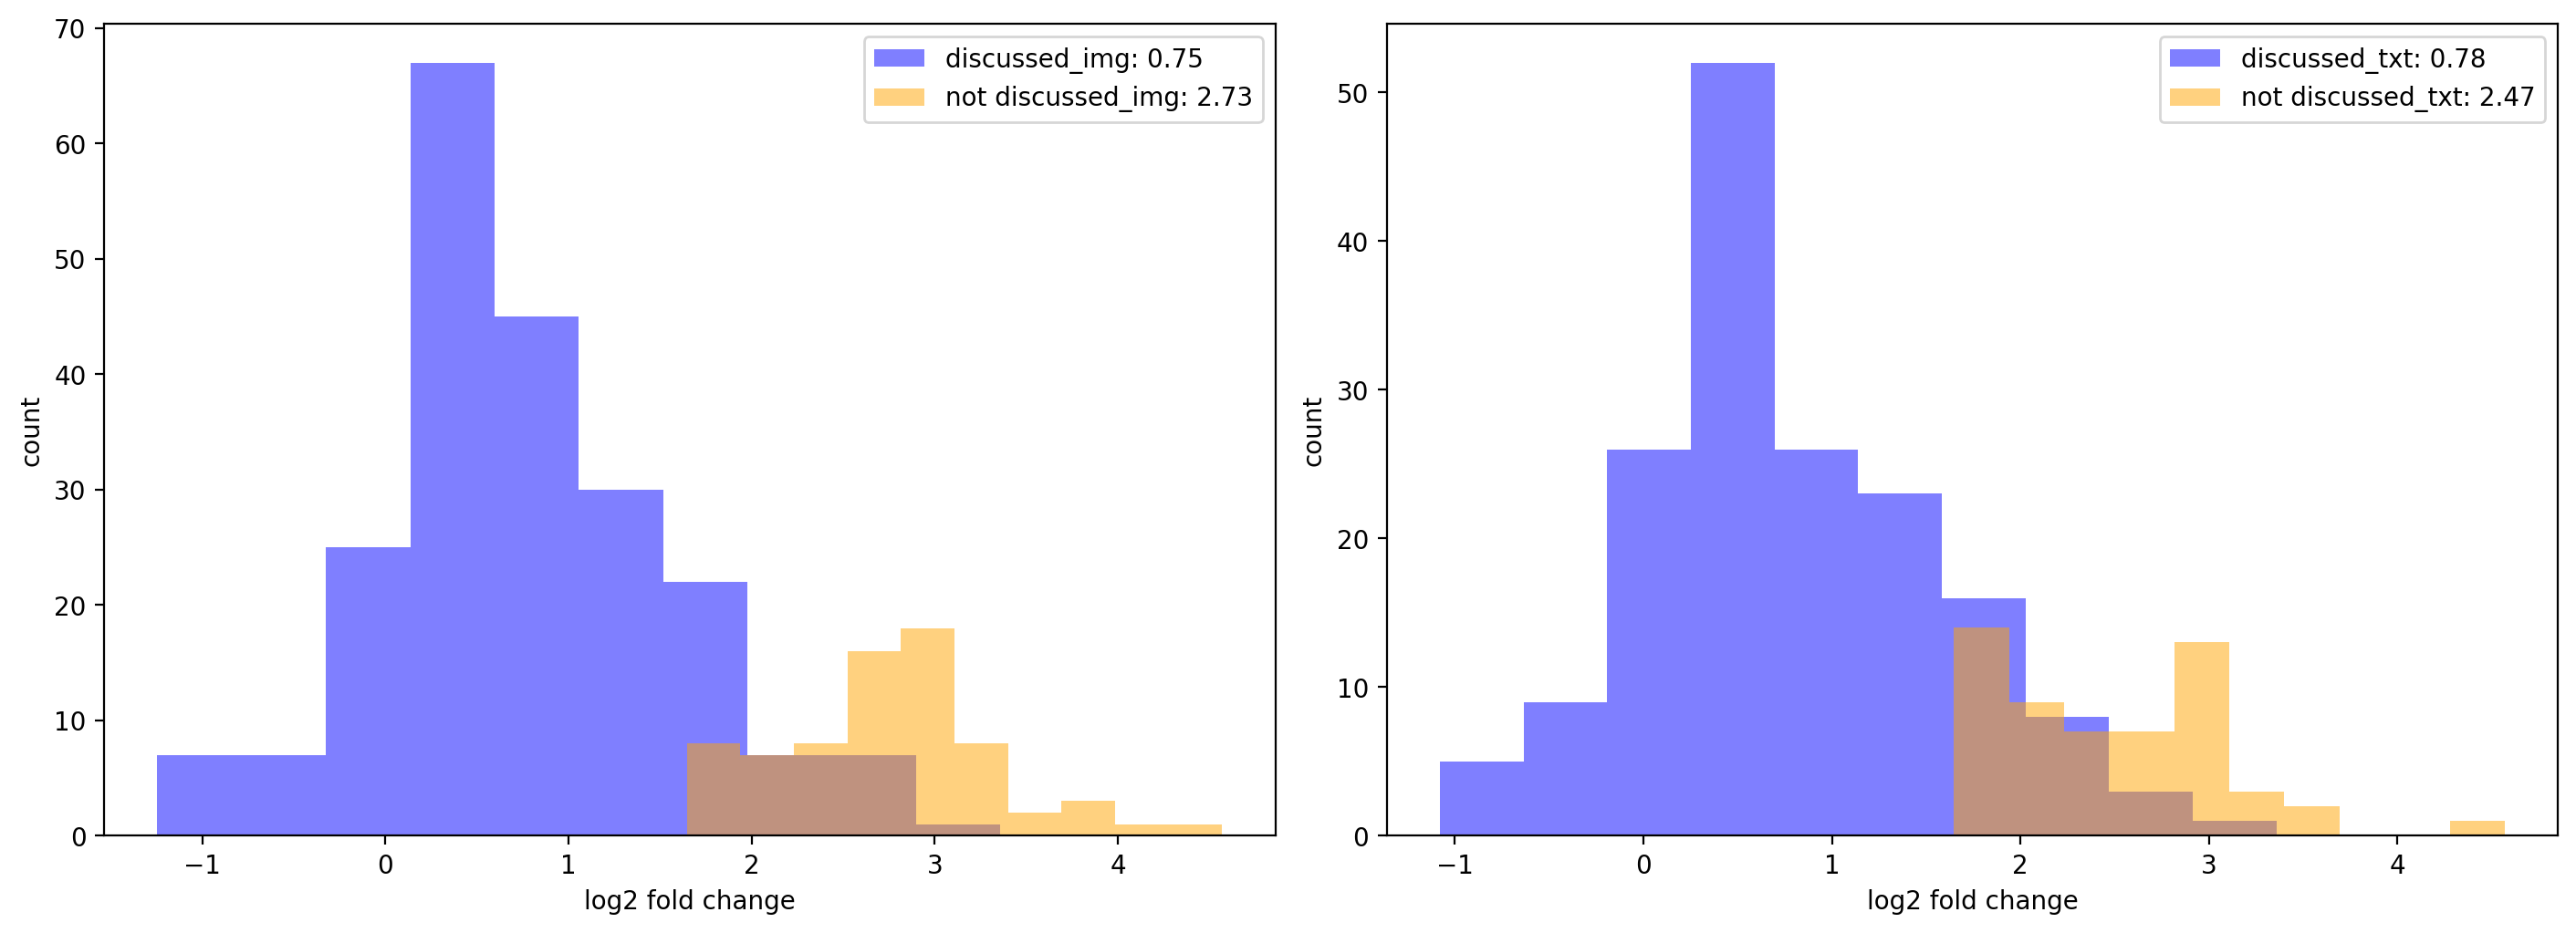

In [125]:
fig, axs = plt.subplots(figsize=(14, 5), ncols=2, constrained_layout=True)

ax = axs[0]
x = discussed_img["log_fc"]
mean = np.mean(x)
ax.hist(x, alpha=0.5, color="blue", label=f"discussed_img: {mean:.2f}")


x = not_discussed_img["log_fc"]

mean = np.mean(x)
ax.hist(x, alpha=0.5, color="orange", label=f"not discussed_img: {mean:.2f}")

ax.set(**{
    "xlabel": "log2 fold change",
    "ylabel": "count",

})
ax.legend()

ax = axs[1]
x = discussed_txt["log_fc"]
mean = np.mean(x)
ax.hist(x, alpha=0.5, color="blue", label=f"discussed_txt: {mean:.2f}")


x = not_discussed_txt["log_fc"]

mean = np.mean(x)
ax.hist(x, alpha=0.5, color="orange", label=f"not discussed_txt: {mean:.2f}")

ax.set(**{
    "xlabel": "log2 fold change",
    "ylabel": "count",

})
ax.legend()
plt.show()

In [44]:
gb_discussed = discussed.groupby("cell_type_id").agg({"log_fc": "mean", "p_corr": "mean"})
gb_not_discussed = not_discussed.groupby("cell_type_id").agg({"log_fc": "mean",
 "p_corr": "mean"}).loc[gb_discussed.index]

In [45]:
v_discussed = discussed.groupby("cell_type_id")["log_fc"].apply(list)
v_not_discussed = not_discussed.groupby("cell_type_id")["log_fc"].apply(list).loc[v_discussed.index]

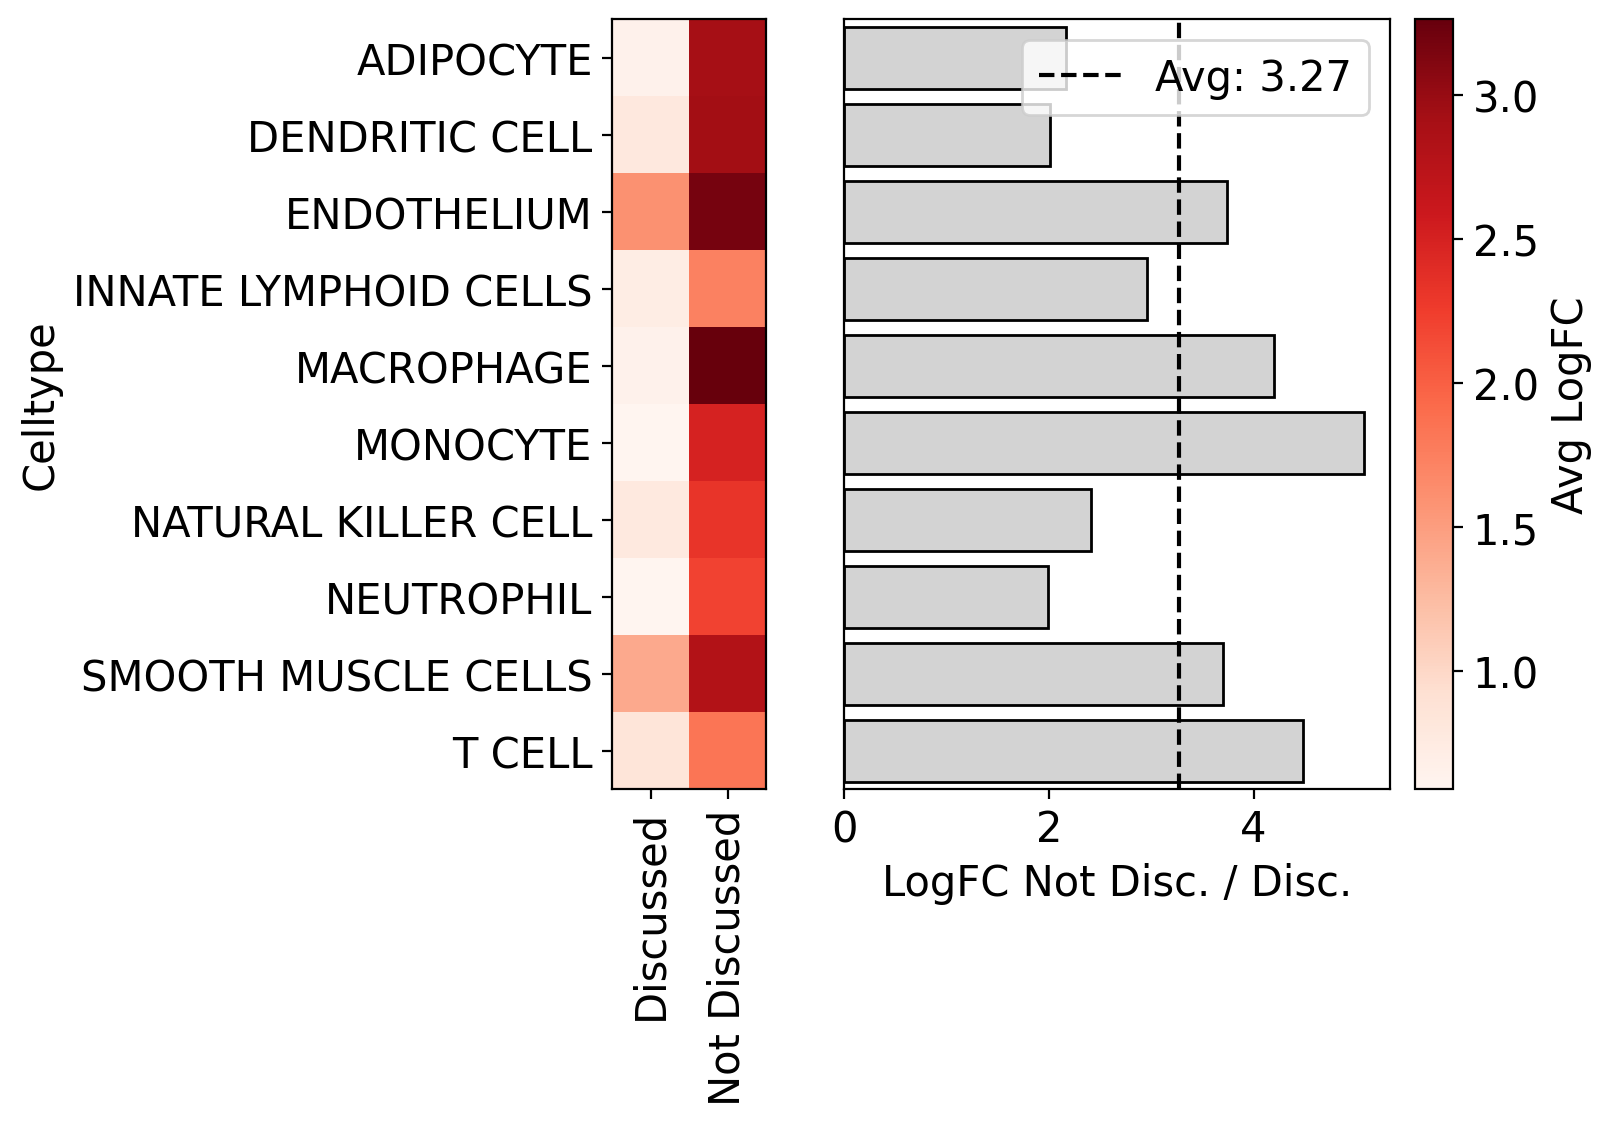

In [46]:
fig, axs = plt.subplots(figsize=(7, 5), ncols=2)
fig.subplots_adjust(hspace=0, wspace=-0.25)

ax = axs[0]
x = gb_discussed["log_fc"].values
y = gb_not_discussed["log_fc"].values
data = np.stack([x, y]).T

cax = ax.imshow(data, cmap="Reds")
ax.set(**{
    # "title": f"Avg. LogFC",
    "ylabel": f"Celltype",
    "xticks": [0,1],
    "xticklabels": ["Discussed", "Not Discussed"],
    "yticks": np.arange(len(gb_discussed)),
    "yticklabels": gb_discussed.index
})
ax.set_yticklabels(ax.get_yticklabels(), ha='right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')

ax = axs[1]
ratio = data[:,1] / data[:,0]

ax.barh(np.arange(len(gb_discussed)), ratio, edgecolor="black", facecolor="lightgrey")
ax.axvline(x=ratio.mean(), color="black", linestyle="--", label=f"Avg: {ratio.mean():,.2f}")
ax.set(**{
    "yticks": np.arange(len(gb_discussed)),
    "yticklabels": [],
    "xlabel": "LogFC Not Disc. / Disc.",
    "ylim": (-0.5, len(gb_discussed)-0.5)
})
ax.yaxis.set_visible(False)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.colorbar(cax, ax=ax, fraction=0.08, pad=0.04, label="Avg LogFC")
ax.legend()
plt.show()


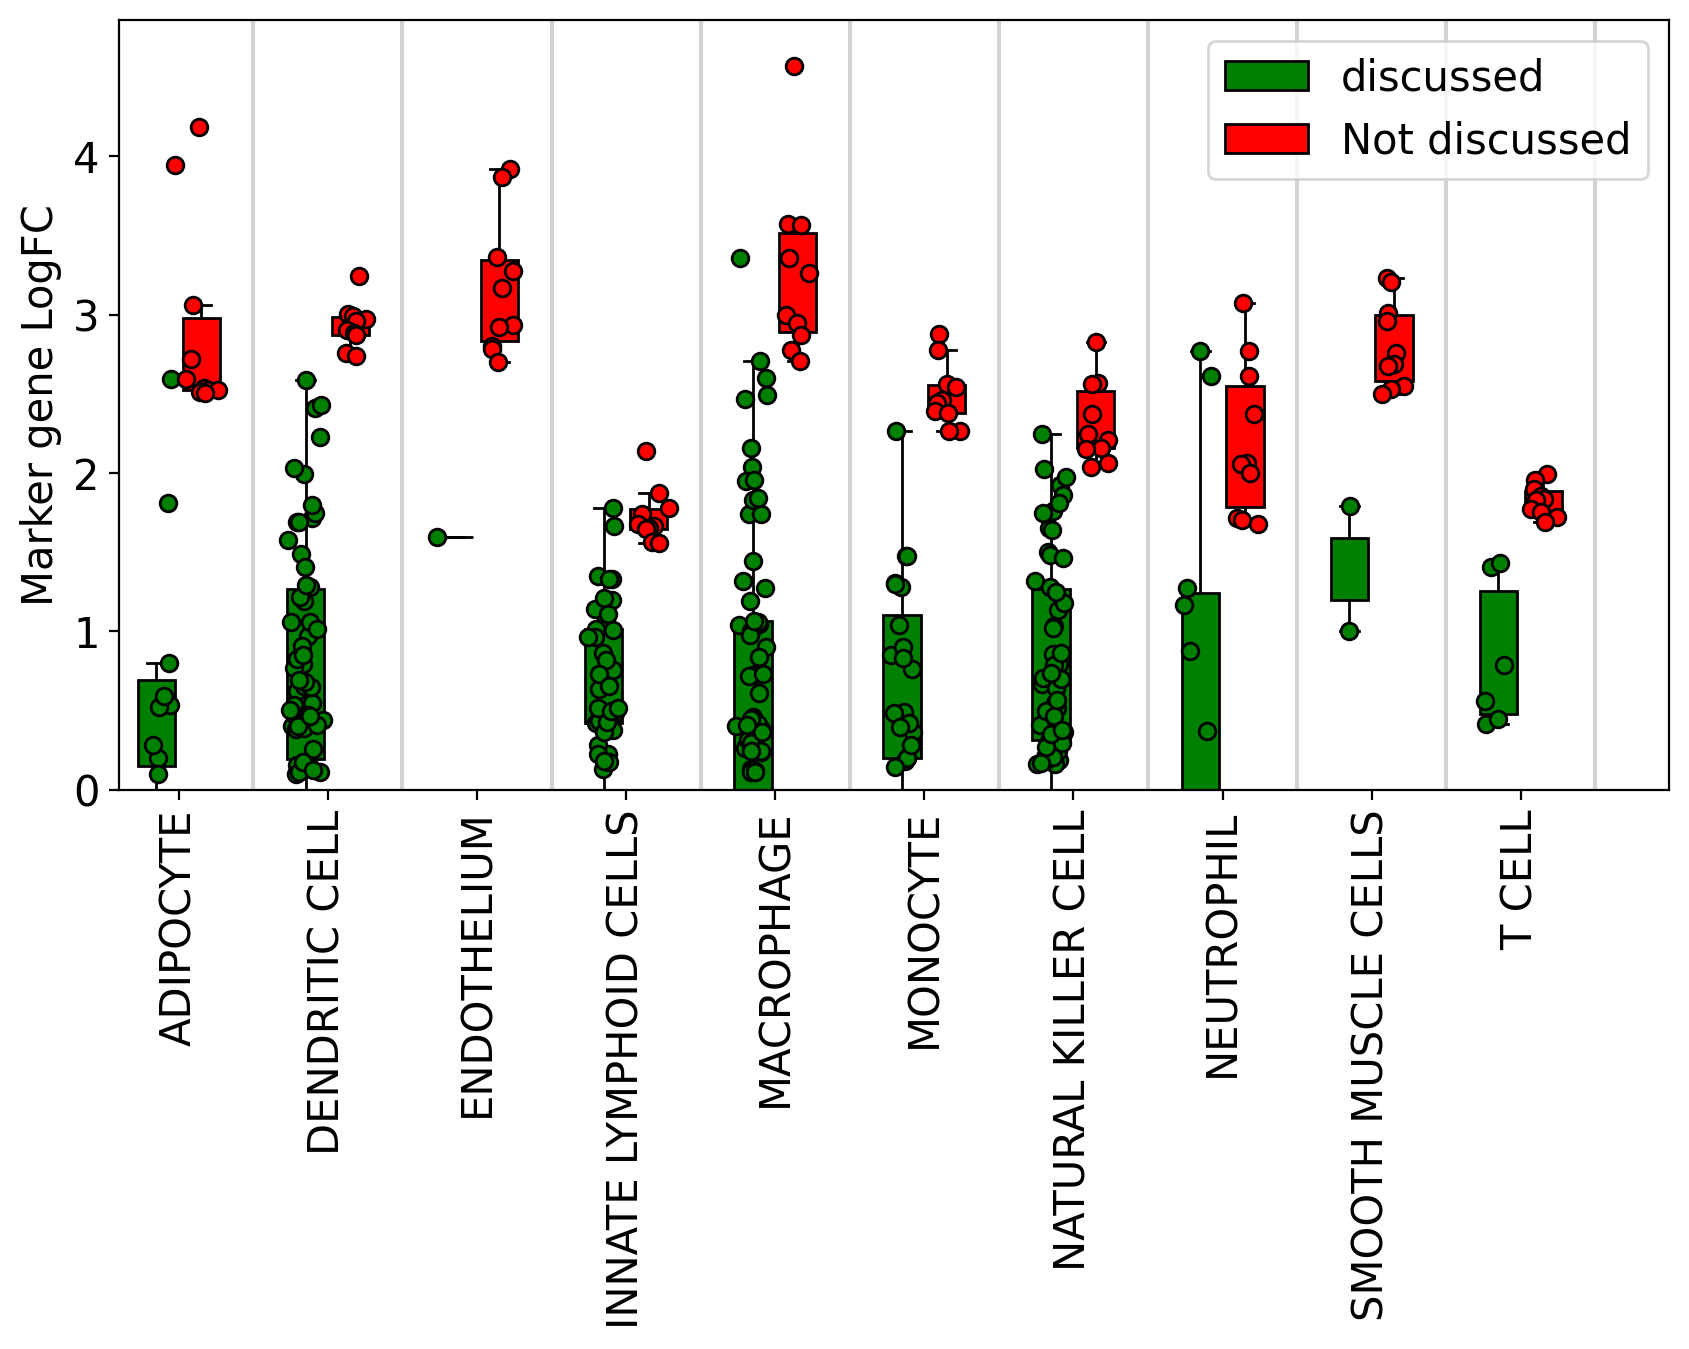

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))

dist_bw = 2
space = 0.3

# Data preparation
labels = v_discussed.index
x = v_discussed.values
y = v_not_discussed.values

idx = np.arange(len(labels)) * dist_bw

# Boxplots
ax.boxplot(x, positions=idx - space, widths=0.5, patch_artist=True, medianprops={'visible': False}, boxprops=dict(facecolor='green'), label="discussed", showfliers=False)
ax.boxplot(y, positions=idx + space, widths=0.5, patch_artist=True, medianprops={'visible': False}, boxprops=dict(facecolor='red'), label="Not discussed", showfliers=False)

for i, xx, yy in zip(idx, x, y):
    xxx = np.random.normal(i-space, 0.1, size=len(xx))
    yyy = np.random.normal(i+space, 0.1, size=len(yy))
    ax.scatter(xxx, xx, edgecolor="k", facecolor="green", zorder=10)
    ax.scatter(yyy, yy, edgecolor="k", facecolor="red", zorder=10)


# Formatting
ax.set(**{
    "xticks": np.arange(len(labels)) * dist_bw,
    "xticklabels": labels,
    "ylabel": "Marker gene LogFC"
})
for v in  np.arange(len(labels)) * dist_bw + dist_bw/2:
    ax.axvline(v, color="lightgrey")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')

ax.set_ylim(bottom=0)

ax.legend()
plt.show()

In [ ]:
import json

with open("../ctmap/rev_ctmap.json", "r") as f:
    ctmap = json.load(f)
    
with open("evidence_unfiltered_metrics.json", "r") as f:
    evidence = json.load(f)

for item in evidence:
    e,d,s = item.keys()
    item[d]["cell_type_id"] = ctmap.get(item[d]["cell_type_label"].upper(), item[d]["cell_type_label"].upper())

with open("evidence_unfiltered_metrics.json", "w") as f:
    json.dump(evidence, f, indent = 4)

## Cell-type-specific comparisons

In [234]:
def ctg_metric(df1, df2, gene_col = "feature_name", ct_col = "cell_type_label", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True, vals=False):
    # common cell types
    common_ct = np.intersect1d(df1[ct_col].unique(), df2[ct_col].unique())
    common_gn = np.intersect1d(df1[gene_col].unique(), df2[gene_col].unique())


    # comm_df1 = df1[df1[ct_col].isin(common_ct)]
    # comm_df2 = df2[df2[ct_col].isin(common_ct)]
    
    # here we filter for the same set of cell types and genes <-- note we may want to change this!
    if comm_ct and not comm_gene:
        comm_df1 = df1[df1[ct_col].isin(common_ct)]
        comm_df2 = df2[df2[ct_col].isin(common_ct)]
    elif comm_gene and not comm_ct:
        comm_df1 = df1[df1[gene_col].isin(common_gn)]
        comm_df2 = df2[df2[gene_col].isin(common_gn)]
    elif comm_ct and comm_gene:
        comm_df1 = df1[df1[ct_col].isin(common_ct) & df1[gene_col].isin(common_gn)]
        comm_df2 = df2[df2[ct_col].isin(common_ct) & df2[gene_col].isin(common_gn)]
    else:
        comm_df1 = df1
        comm_df2 = df2

    df1_ctg_list = comm_df1.groupby(ct_col)[gene_col].apply(lambda x: x.unique())
    if comm_ct:
        df1_ctg_list = df1_ctg_list.reindex(common_ct, fill_value=[])
    df2_ctg_list = comm_df2.groupby(ct_col)[gene_col].apply(lambda x: x.unique())
    if comm_ct:
        df2_ctg_list = df2_ctg_list.reindex(common_ct, fill_value=[])

    # now take the left set diff, intersection, and right set diff for every pair of cell types in the two dataframes
    ctg_cmp = {}
    ctg_cmp_vals = {}
    for ct1 in df1_ctg_list.index:
        for ct2 in df2_ctg_list.index:
            l, x, r  = set_cmp(df1_ctg_list[ct1], df2_ctg_list[ct2])
            lv, xv, rv  = set_cmp(df1_ctg_list[ct1], df2_ctg_list[ct2], vals=True)
            ctg_cmp[(ct1, ct2)] = (l, x, r)
            ctg_cmp_vals[(ct1, ct1)] = (lv, xv, rv)

    if vals:
        return ctg_cmp_vals
    
    pvt = pd.DataFrame(ctg_cmp.values(), index=ctg_cmp.keys(), columns=["l", "x", "r"]).reset_index(names=[df1_label, df2_label]).pivot(index=df1_label, columns=df2_label, values=["l", "x", "r"]).fillna(0)

    df1_ct = pvt.index
    df2_ct = pvt.columns.levels[1]
    mtx = pvt.to_numpy().reshape(len(df1_ct), 3, len(df2_ct))
    norm_mtx = mtx / mtx.sum(axis=1)[:, np.newaxis, :]
    mtx = mtx.transpose(0,2,1)
    norm_mtx = norm_mtx.transpose(0,2,1)
    return (mtx, norm_mtx, df1_ct, df2_ct)

## All "OG" cell type names between human and DEG

In [163]:
deg["feature_identifier"].isna().sum(), hmn["feature_identifier"].isna().sum()

(np.int64(0), np.int64(0))

In [164]:
(mtx, norm_mtx, hmnct, degct) = ctg_metric(hmn, deg, gene_col = "feature_identifier", ct_col = "cell_type_id", 
df1_label="hmn", df2_label="deg", comm_ct=False, comm_gene=True)
df = pd.DataFrame(mtx.tolist(), index=hmnct, columns=degct)
df.head()

deg,CHONDROCYTE,ENDOTHELIUM,EPITHELIUM,ERYTHROCYTE,LIMB BUD MESENCHYMAL CELL,MACROPHAGE,MYOCYTE,NATURAL KILLER CELL,NEURAL CREST CELL,PERICYTE,PROGENITOR CELLS,SCHWANN CELL,STROMAL CELLS,VASCULAR CELLS
hmn,,,,,,,,,,,,,,
CHONDROCYTE,"[23, 6, 0]","[28, 1, 0]","[29, 0, 2]","[29, 0, 1]","[23, 6, 4]","[28, 1, 0]","[25, 4, 1]","[27, 2, 0]","[27, 2, 1]","[28, 1, 2]","[22, 7, 14]","[29, 0, 4]","[22, 7, 8]","[27, 2, 0]"
ENDOTHELIUM,"[20, 1, 5]","[20, 1, 0]","[21, 0, 2]","[21, 0, 1]","[15, 6, 4]","[20, 1, 0]","[19, 2, 3]","[20, 1, 1]","[19, 2, 1]","[20, 1, 2]","[14, 7, 14]","[21, 0, 4]","[16, 5, 10]","[19, 2, 0]"
EPITHELIUM,"[7, 1, 5]","[8, 0, 1]","[6, 2, 0]","[8, 0, 1]","[4, 4, 6]","[8, 0, 1]","[8, 0, 5]","[8, 0, 2]","[8, 0, 3]","[8, 0, 3]","[6, 2, 19]","[8, 0, 4]","[7, 1, 14]","[8, 0, 2]"
ERYTHROCYTE,"[6, 1, 5]","[7, 0, 1]","[6, 1, 1]","[6, 1, 0]","[4, 3, 7]","[7, 0, 1]","[7, 0, 5]","[7, 0, 2]","[7, 0, 3]","[7, 0, 3]","[5, 2, 19]","[7, 0, 4]","[6, 1, 14]","[7, 0, 2]"
LIMB BUD MESENCHYMAL CELL,"[14, 1, 5]","[15, 0, 1]","[15, 0, 2]","[15, 0, 1]","[8, 7, 3]","[15, 0, 1]","[14, 1, 4]","[15, 0, 2]","[15, 0, 3]","[15, 0, 3]","[9, 6, 15]","[15, 0, 4]","[7, 8, 7]","[15, 0, 2]"


# All consistent Cell Types

In [268]:
(mtx, norm_mtx, hmnct, degct) = ctg_metric(hmn, deg, gene_col = "feature_identifier", ct_col = "cell_type_id", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True, vals=False)

df = pd.DataFrame(mtx.tolist(), index=hmnct, columns=degct)
df.head()

deg,ADIPOCYTE,DENDRITIC CELL,ENDOTHELIUM,INNATE LYMPHOID CELLS,MACROPHAGE,MONOCYTE,NATURAL KILLER CELL,NEUTROPHIL,SMOOTH MUSCLE CELLS,T CELL
hmn,,,,,,,,,,
ADIPOCYTE,"[0, 4, 9]","[4, 0, 38]","[4, 0, 10]","[4, 0, 27]","[2, 2, 36]","[4, 0, 29]","[4, 0, 26]","[4, 0, 15]","[4, 0, 9]","[4, 0, 27]"
DENDRITIC CELL,"[24, 3, 10]","[2, 25, 13]","[25, 2, 8]","[21, 6, 21]","[15, 12, 26]","[17, 10, 19]","[19, 8, 18]","[23, 4, 11]","[27, 0, 9]","[20, 7, 20]"
ENDOTHELIUM,"[1, 1, 12]","[2, 0, 38]","[1, 1, 9]","[2, 0, 27]","[1, 1, 37]","[2, 0, 29]","[2, 0, 26]","[2, 0, 15]","[2, 0, 9]","[2, 0, 27]"
INNATE LYMPHOID CELLS,"[12, 1, 12]","[10, 3, 35]","[12, 1, 9]","[0, 13, 14]","[11, 2, 36]","[13, 0, 29]","[9, 4, 22]","[12, 1, 14]","[13, 0, 9]","[7, 6, 21]"
MACROPHAGE,"[13, 5, 8]","[8, 10, 28]","[13, 5, 5]","[16, 2, 25]","[0, 18, 20]","[7, 11, 18]","[16, 2, 24]","[13, 5, 10]","[13, 5, 4]","[15, 3, 24]"


In [556]:
vals = ctg_metric(hmn, deg, gene_col = "feature_identifier", ct_col = "cell_type_id", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True, vals=True)
comm = pd.DataFrame(vals.values(), index=vals.keys(), columns=["l", "x", "r"]).reset_index(names=["hmn", "deg"]).query("hmn==deg").set_index(["hmn"])["x"].explode().dropna()

discussed = deg[deg.apply(lambda row: (row["cell_type_id"], row["feature_identifier"]) in set(comm.items()), axis=1)].drop_duplicates(["cell_type_id", "feature_identifier"])
not_discussed = deg.query("p_corr < 0.01").groupby("cell_type_id").apply(lambda x: x.nlargest(5, "log_fc")).reset_index(drop=True)

In [557]:
discussed.shape

(19, 16)

Break this result down by cell type

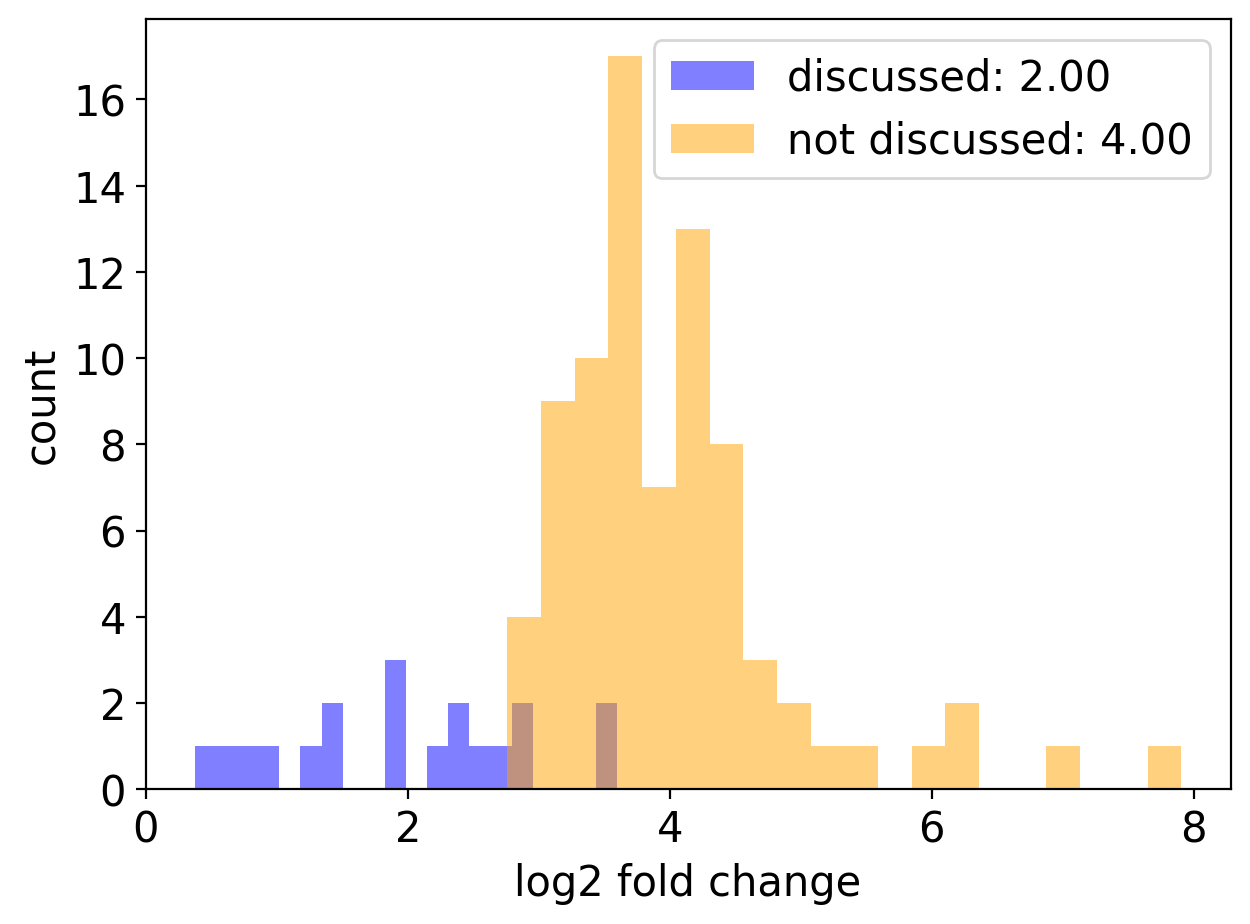

In [491]:
fig, ax = plt.subplots(figsize=(7, 5))

x = discussed["log_fc"]
mean = np.mean(x)
ax.hist(x, bins=20, alpha=0.5, color="blue", label=f"discussed: {mean:.2f}")


x = not_discussed["log_fc"]

mean = np.mean(x)
ax.hist(x, bins=20, alpha=0.5, color="orange", label=f"not discussed: {mean:.2f}")

ax.set(**{
    "xlabel": "log2 fold change",
    "ylabel": "count",

})
ax.legend()
plt.show()

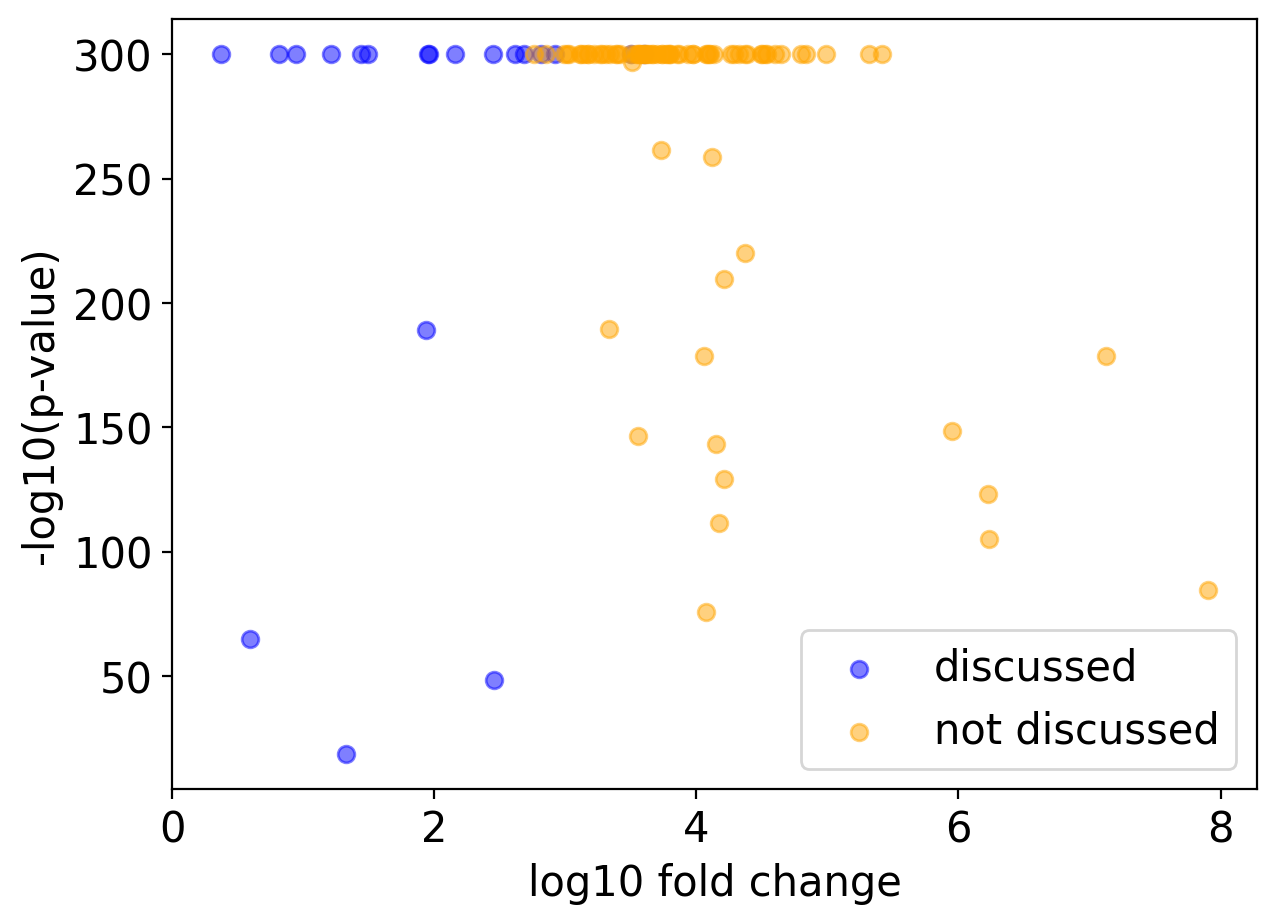

In [154]:
import numpy as np
import matplotlib.pyplot as plt

# Define a very small number to replace zeros
min_pval = 1e-300

# Replace zeros in the p-values with the minimum p-value
discussed_p = discussed["p_corr"].replace(0, min_pval)
not_discussed_p = not_discussed["p_corr"].replace(0, min_pval)

fig, ax = plt.subplots(figsize=(7, 5))

# Use np.log10 for a volcano plot (-log10(p))
x_discussed = discussed["log_fc"]
y_discussed = -np.log10(discussed_p)
ax.scatter(x_discussed, y_discussed, alpha=0.5, color="blue", label="discussed")

x_not_discussed = not_discussed["log_fc"]
y_not_discussed = -np.log10(not_discussed_p)
ax.scatter(x_not_discussed, y_not_discussed, alpha=0.5, color="orange", label="not discussed")

ax.set(xlabel="log10 fold change", ylabel="-log10(p-value)")
ax.legend()
plt.show()

In [180]:
eye

array([[0.        , 0.30769231, 0.69230769],
       [0.05      , 0.625     , 0.325     ],
       [0.09090909, 0.09090909, 0.81818182],
       [0.        , 0.48148148, 0.51851852],
       [0.        , 0.47368421, 0.52631579],
       [0.03333333, 0.23333333, 0.73333333],
       [0.        , 0.57692308, 0.42307692],
       [0.0625    , 0.375     , 0.5625    ],
       [0.        , 0.22222222, 0.77777778],
       [0.        , 0.07407407, 0.92592593]])

In [188]:
mtx[np.eye(mtx.shape[0], dtype=bool)]

array([[ 0,  4,  9],
       [ 2, 25, 13],
       [ 1,  1,  9],
       [ 0, 13, 14],
       [ 0, 18, 20],
       [ 1,  7, 22],
       [ 0, 15, 11],
       [ 1,  6,  9],
       [ 0,  2,  7],
       [ 0,  2, 25]])

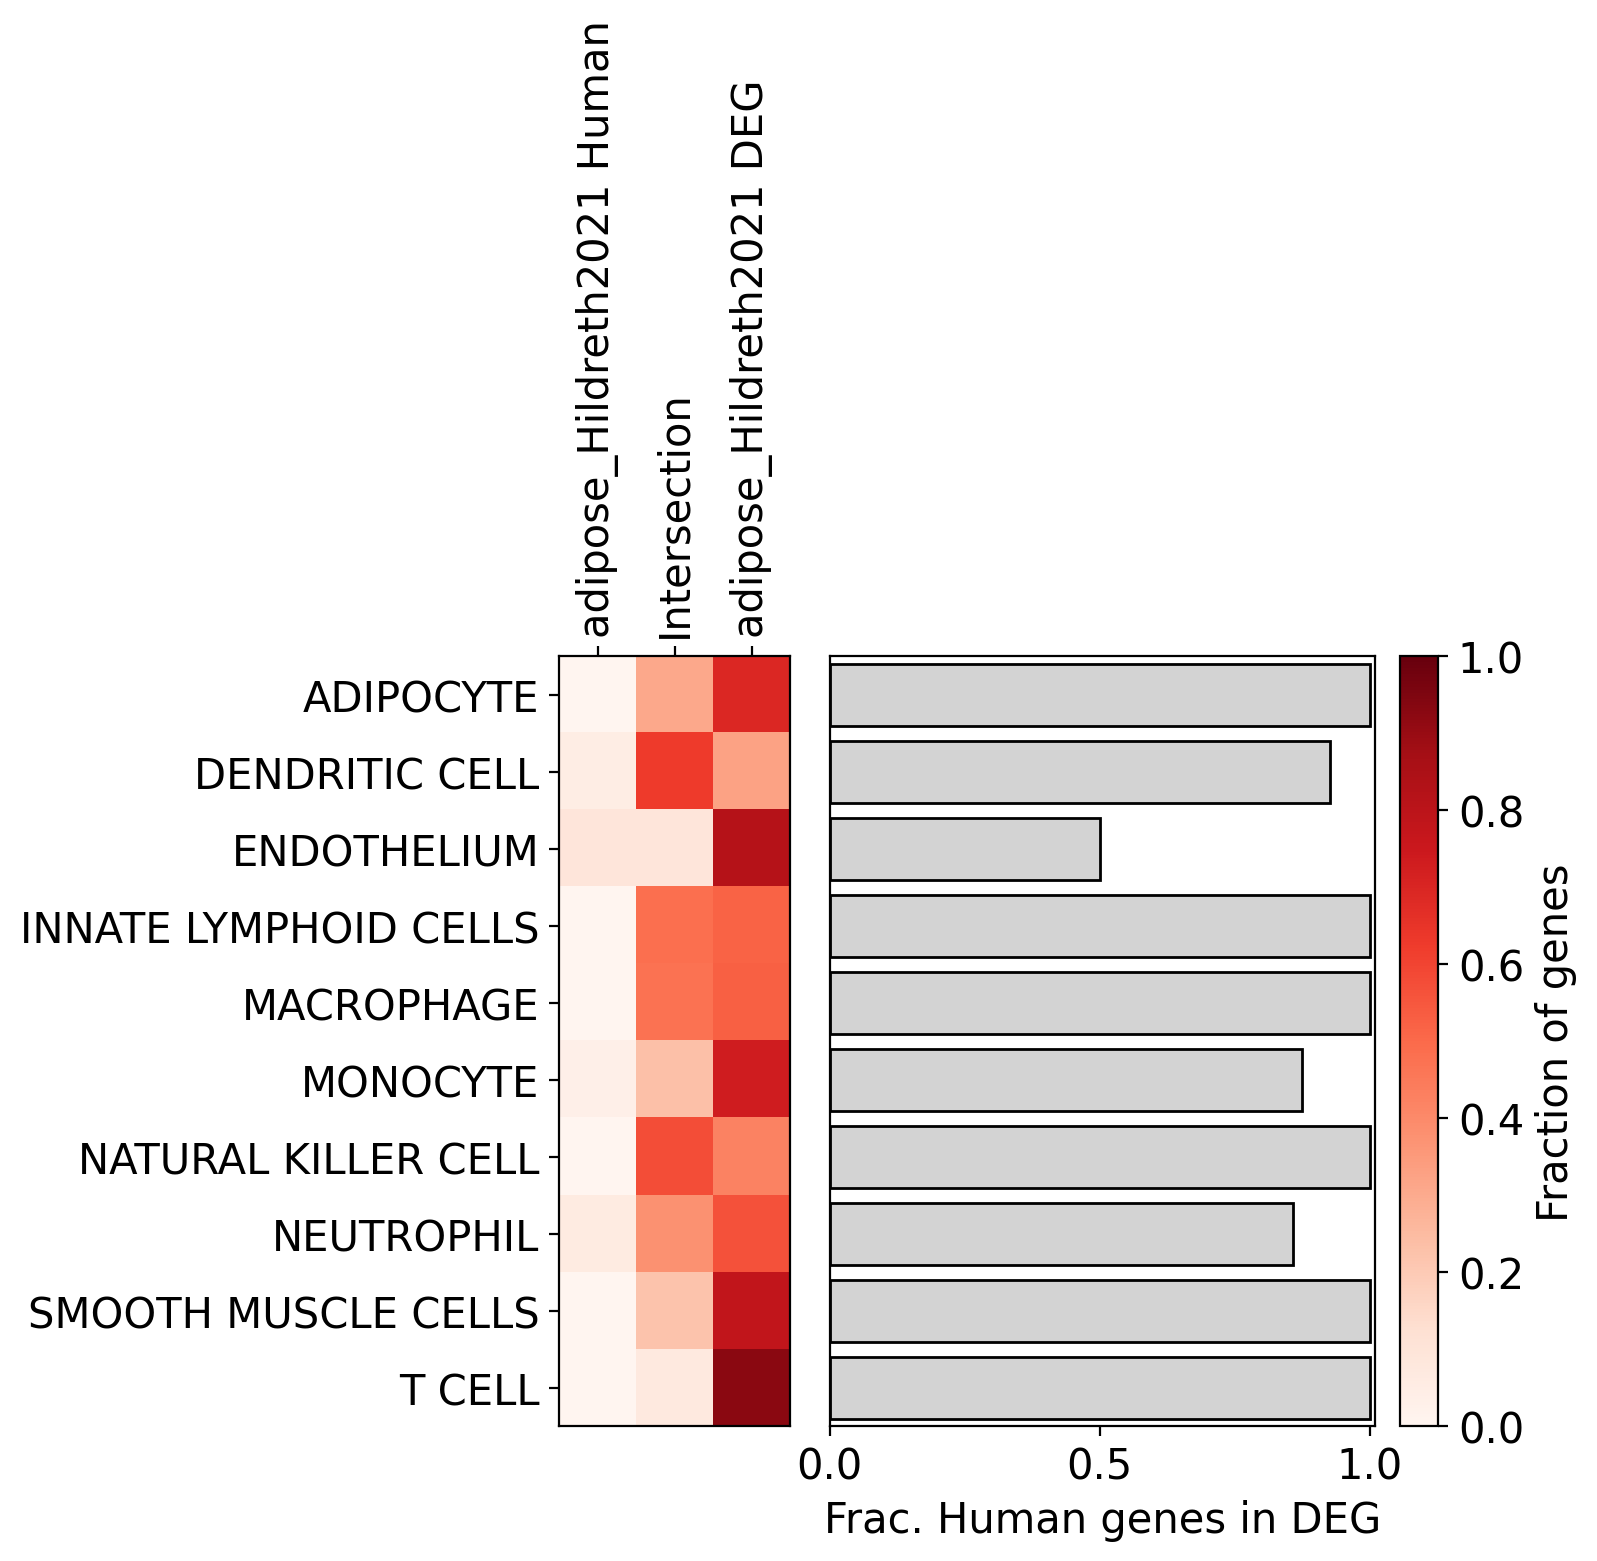

In [269]:
fig, axs = plt.subplots(figsize=(7, 5), ncols=2)
fig.subplots_adjust(hspace=0, wspace=-0.25)

ax = axs[0]
xlabels = [f"{ds_hmn} Human", "Intersection", f"{ds_deg} DEG"]
eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
# eye = mtx[np.eye(mtx.shape[0], dtype=bool)]

cax = ax.imshow(eye, cmap="Reds", vmin=0, vmax=1)

ax.set(**{
    "xticks": np.arange(len(xlabels)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": xlabels,
    "yticklabels": hmnct,
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')  # Set the label position at the top

ax = axs[1]
eye = mtx[np.eye(mtx.shape[0], dtype=bool)]
jac = eye[:,1] / (eye[:,0] + eye[:,1])# + eye[:,2])
# jac = eye[:,1] / (eye[:,1] + eye[:,2])# + eye[:,2])
jac = jac[::-1]

ax.barh(np.arange(len(hmnct)), jac, edgecolor="black", facecolor="lightgrey")
ax.set(**{
    "yticks": np.arange(len(hmnct)),
    "yticklabels": [],
    "xlabel": "Frac. Human genes in DEG",
    # "title": "Jaccard index",
    "xlim": (0,1.01),
    "ylim": (-0.5, len(hmnct)-0.5)
})
ax.yaxis.set_visible(False)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.colorbar(cax, ax=ax, fraction=0.08, pad=0.04, label="Fraction of genes")

plt.show()


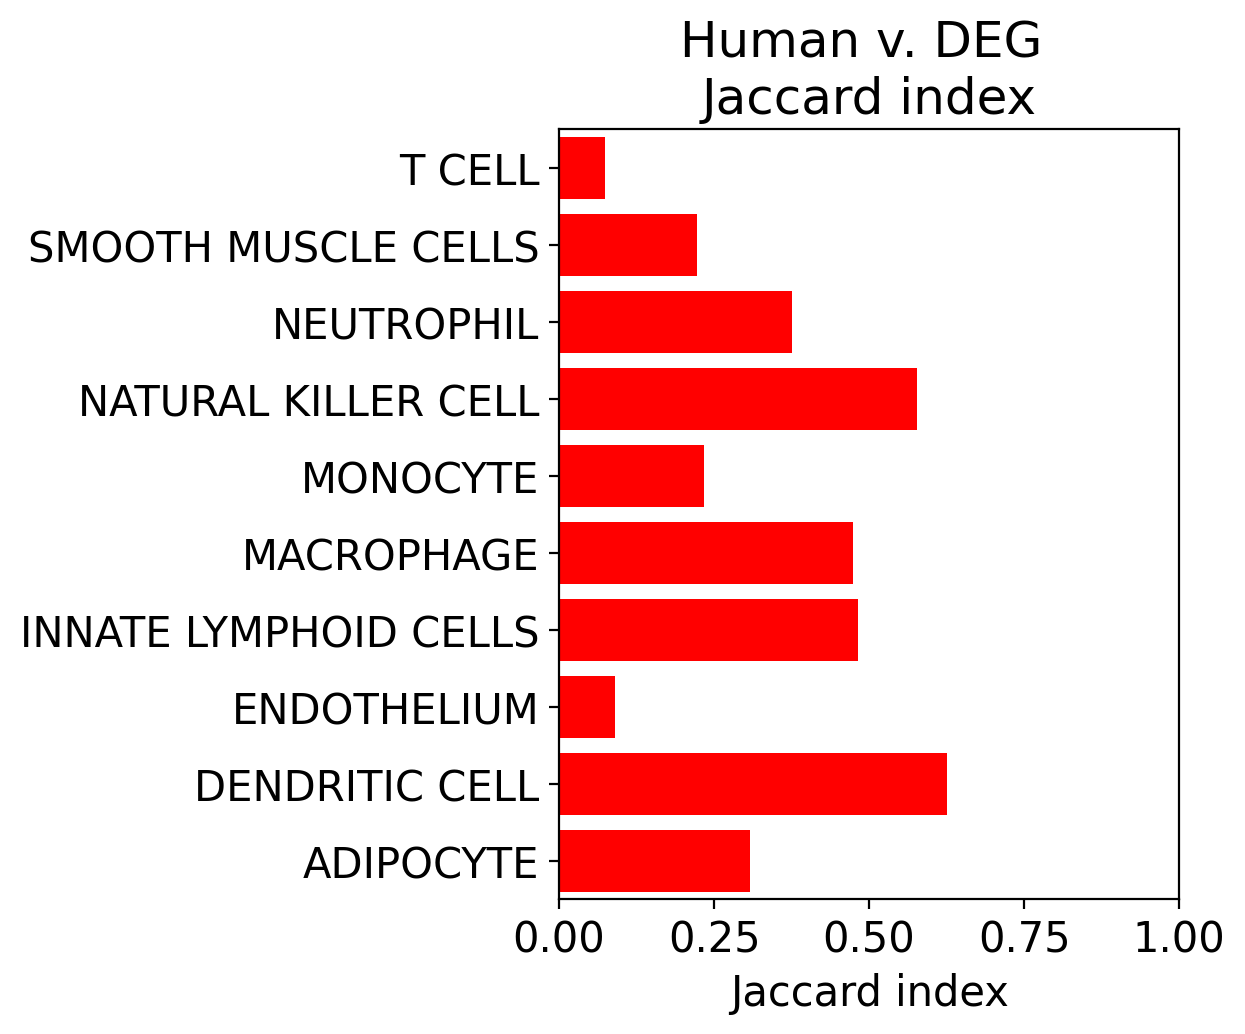

In [191]:
fig, ax = plt.subplots(figsize=(4, 5))

eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
jac = eye[:,1] / (eye[:,0] + eye[:,2] + eye[:,1])

ax.barh(np.arange(len(hmnct)), jac, color="red")
ax.set(**{
    "yticks": np.arange(len(hmnct)),
    "yticklabels": hmnct,
    "xlabel": "Jaccard index",
    "title": "Human v. DEG \nJaccard index",
    "xlim": (0,1),
    "ylim": (-0.5, len(hmnct)-0.5)
})
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.show()


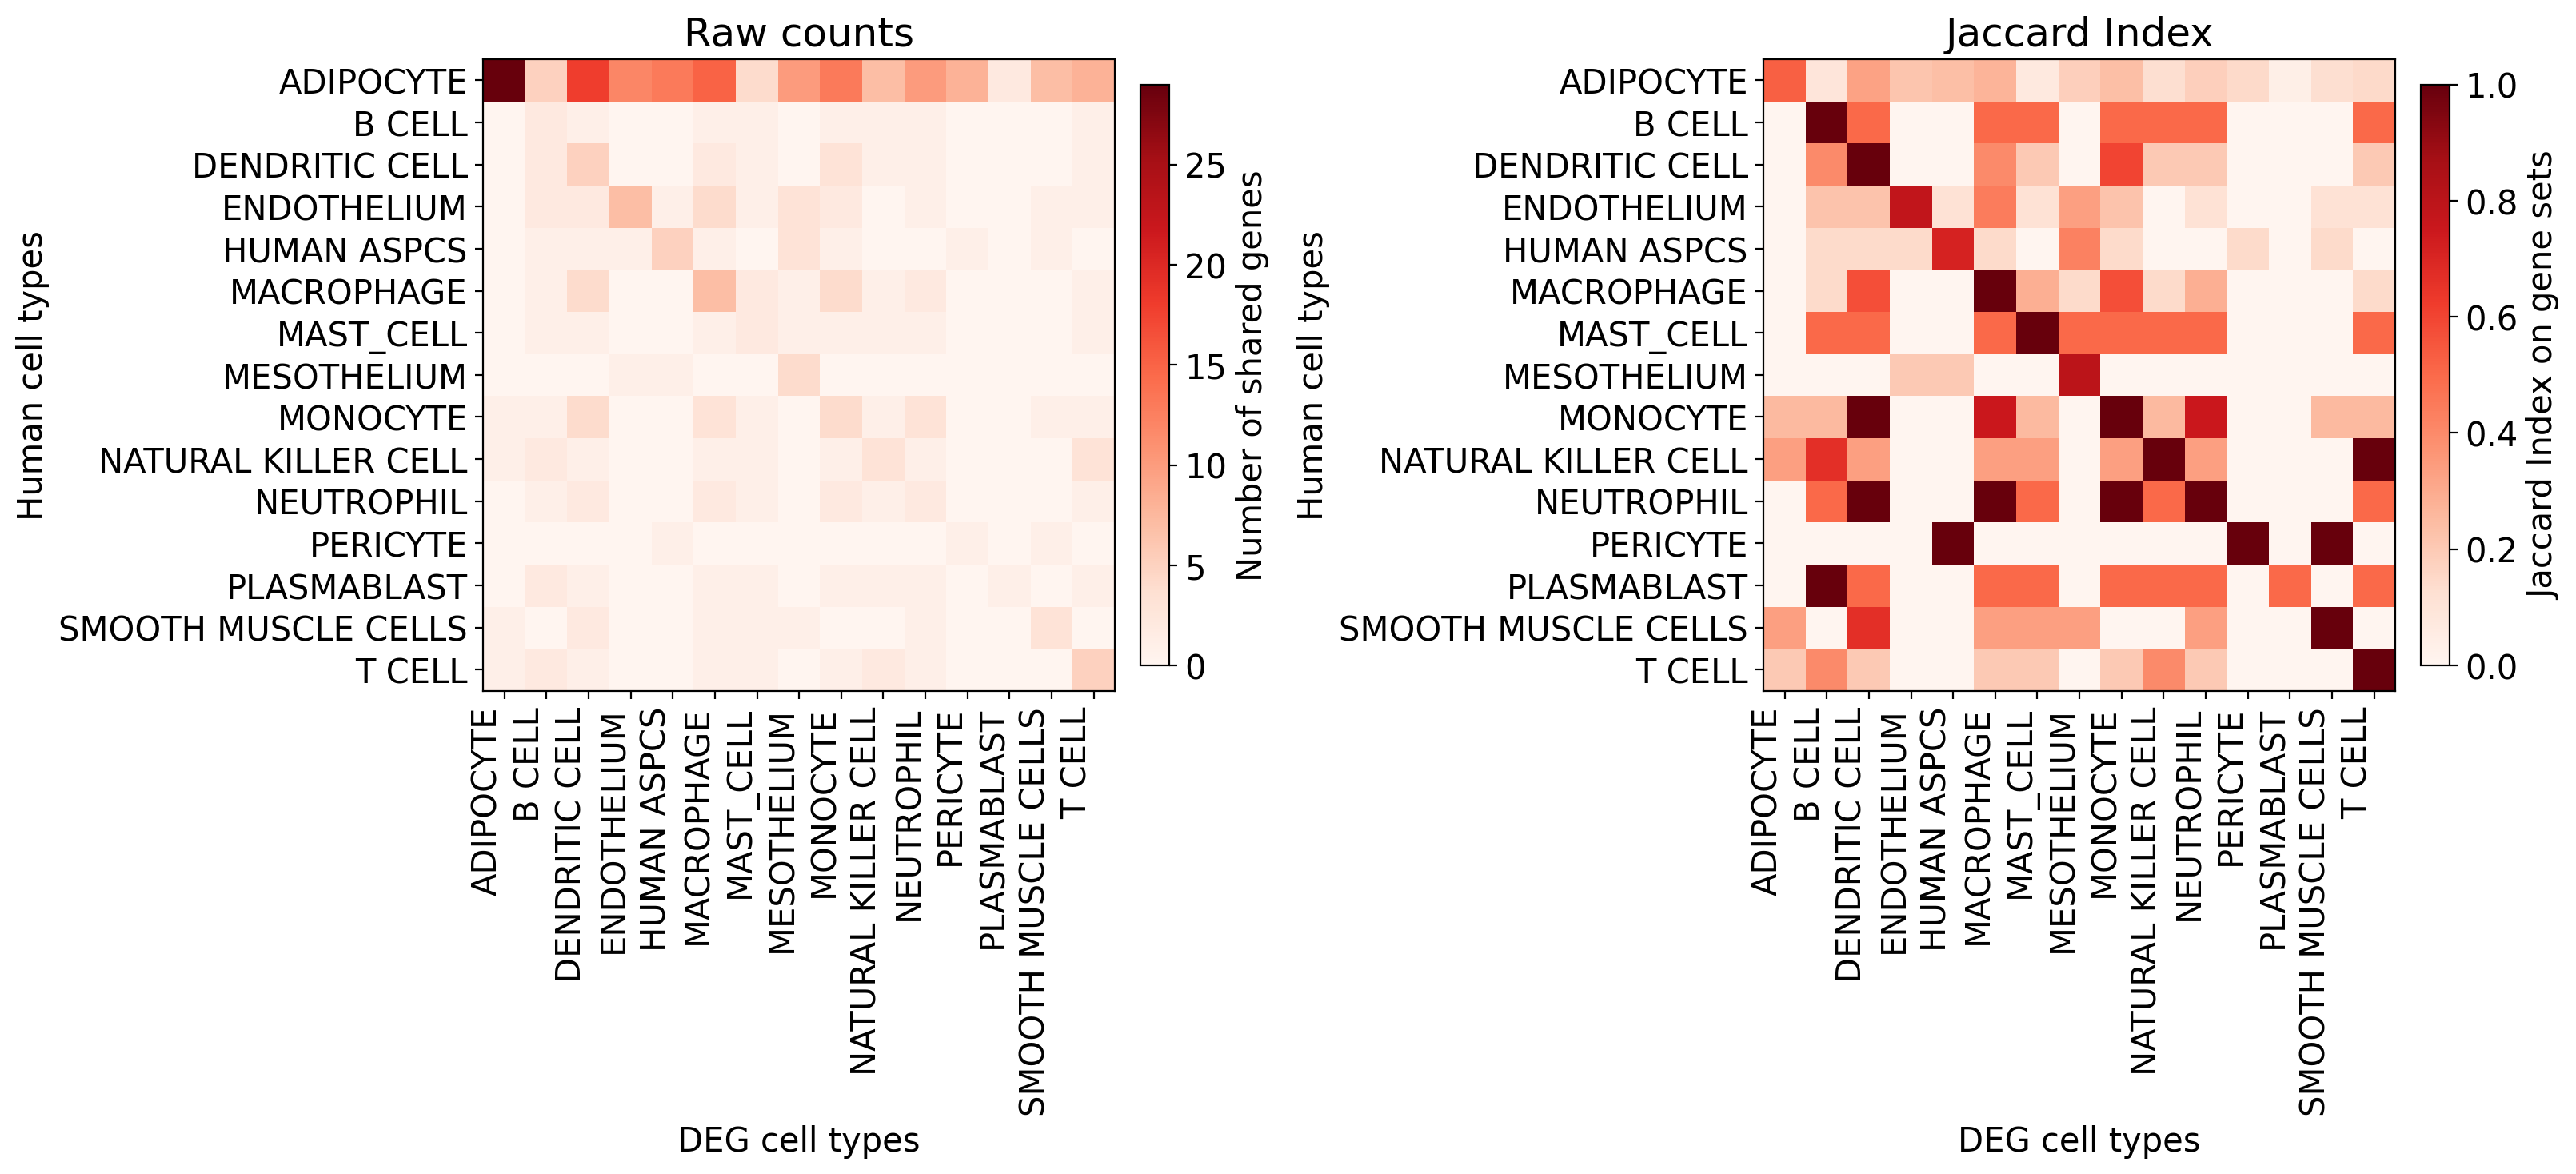

In [237]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, constrained_layout=True)

ax = axs[0]
x = mtx[:,:,1] 
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": degct,
    "yticklabels": hmnct,
    "title": "Raw counts"
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Number of shared genes")

ax = axs[1]
x = mtx[:,:,1] / (mtx[:,:,:2].sum(axis=2))
cax = ax.imshow(x, cmap="Reds", vmin=0, vmax=1)
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": degct,
    "yticklabels": hmnct,
    "title": "Jaccard Index"    
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Jaccard Index on gene sets")
plt.show()


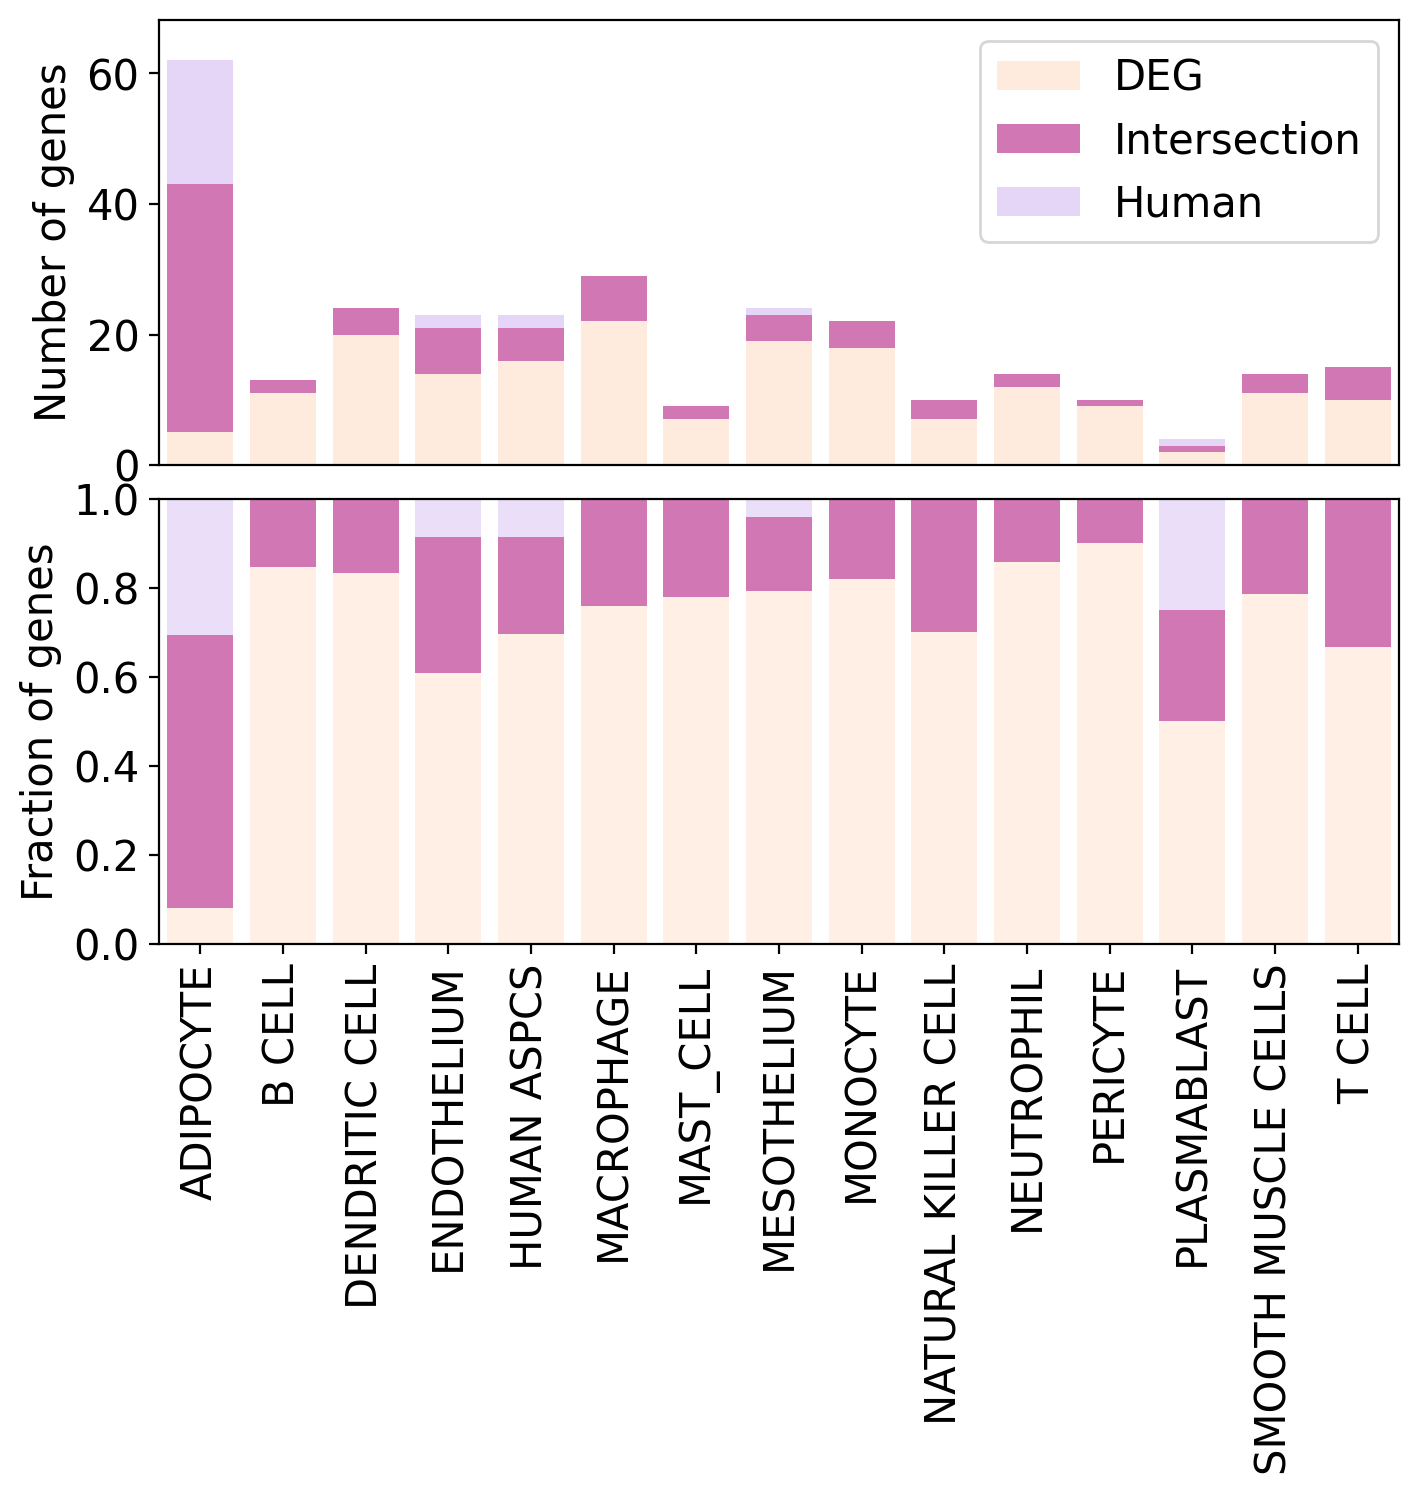

In [83]:
fig, axs = plt.subplots(figsize=(8,6), nrows=2)
fig.subplots_adjust(hspace=0.075, wspace=0.5)
ax = axs[0]
y3 = np.diag(mtx[:,:,0]) # left
y2 = np.diag(mtx[:,:,1]) # itx
y1 = np.diag(mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmnct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.25, label=f'DEG')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.25, label=f'Human')

ax.set(
    **{
        "ylabel": "Number of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1.1 * (y1+y2+y3).max()),
        "xlim": (-0.5, len(x)-0.5)
    }
)
ax.xaxis.set_visible(False)

# ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.legend()#bbox_to_anchor=(1,1))

ax = axs[1]
ax.sharex(axs[0])
y3 = np.diag(norm_mtx[:,:,0]) # left
y2 = np.diag(norm_mtx[:,:,1]) # itx
y1 = np.diag(norm_mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmnct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.2, label=f'DEG')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.2, label=f'Human')

ax.set(
    **{
        "ylabel": "Fraction of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1),
        "xlim": (-0.5, len(x)-0.5)
    }
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Show the plot
plt.show()


## Ternary Plots

In [39]:
norm_mtx.shape

(15, 15, 3)

In [40]:
tmp = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
l = tmp[:,0]
x = tmp[:,1]
r = tmp[:,2]

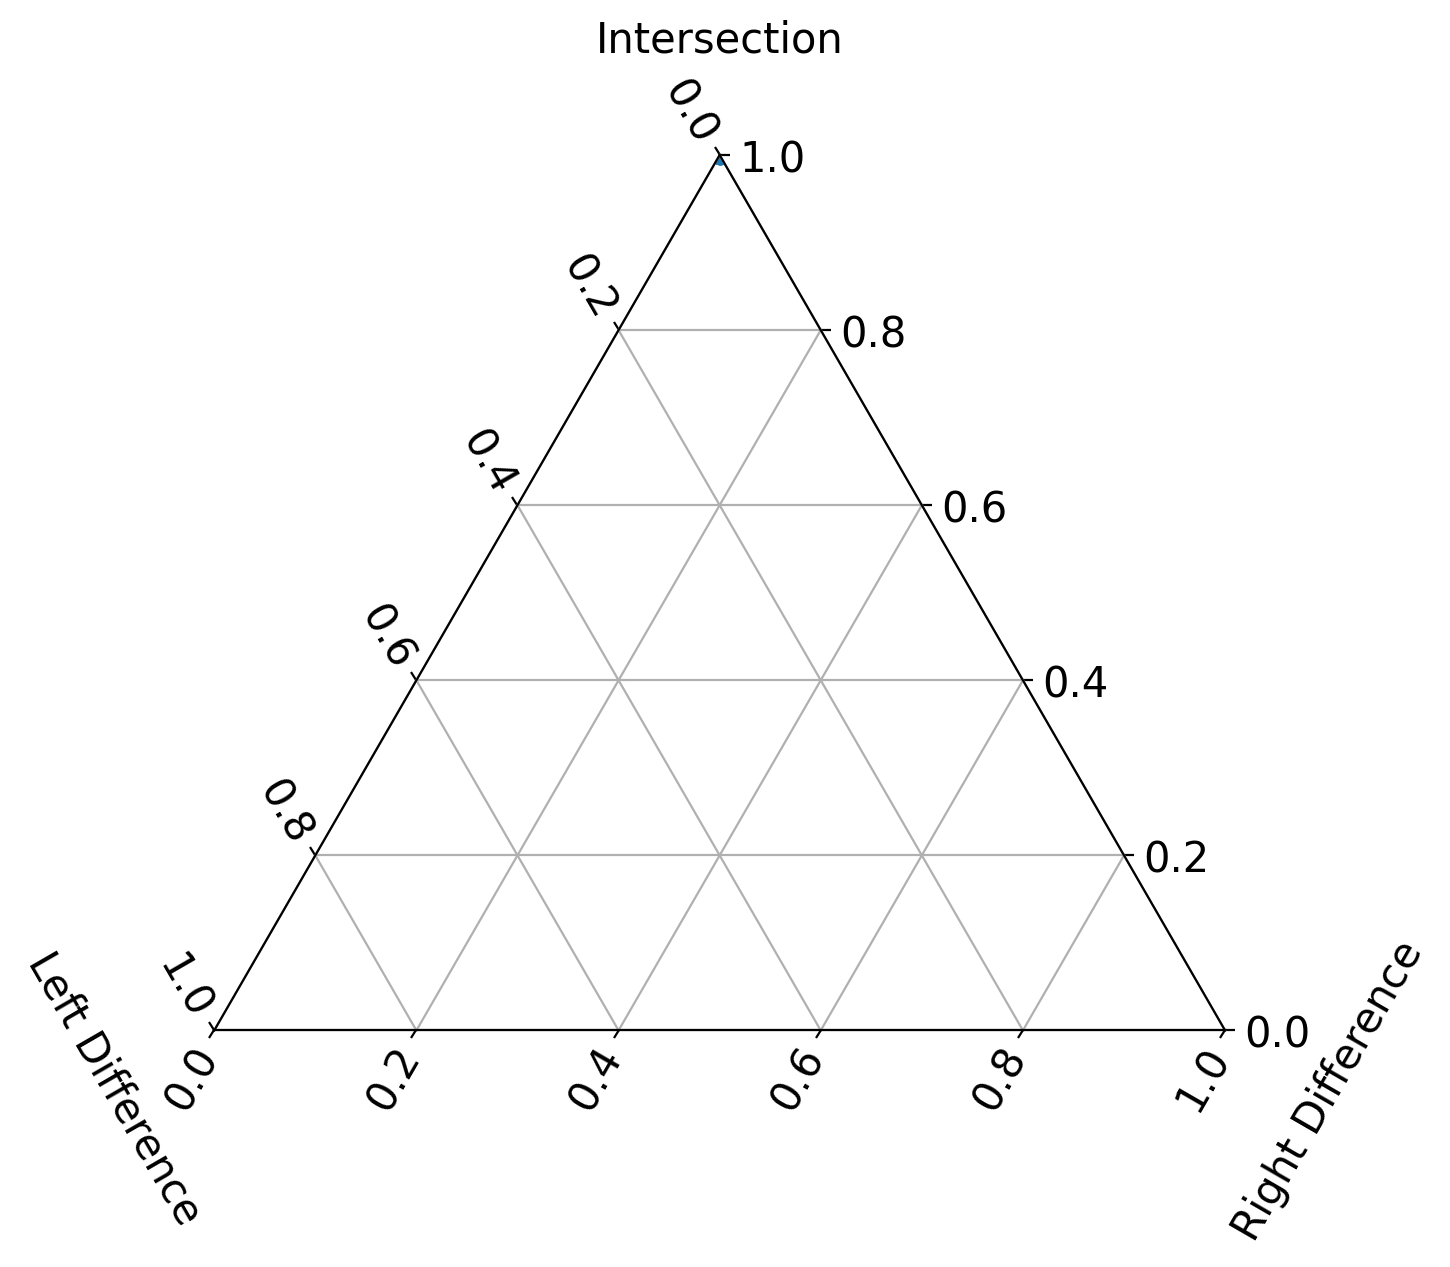

In [41]:
fig = plt.figure(figsize=(15, 15))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)

ax = fig.add_subplot(1, 2, 1, projection="ternary")
pc = ax.scatter(x, l, r, alpha = 0.6, label = f"") # top, left, right

ax.grid(visible=  True, axis = 'both')

ax.set_tlabel('Intersection')
ax.set_llabel('Left Difference')
ax.set_rlabel('Right Difference')

#ax.legend(title = "Gene Expression Set Operations with Same Cell Type Control", fontsize = 'small', bbox_to_anchor=(0, 1, 0, .102))

plt.show()